In [1]:
from pathlib import Path
import pandas as pd
from diffusion_encoder import build_conditional_unet_1d
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence, _wavelet_filter
from dataclasses import replace
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)


I0000 00:00:1779264440.178080   66216 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
import os
from datetime import datetime

# Klasör ismini bugünün tarihiyle oluştur
date_str = datetime.now().strftime("%Y%m%d")
MODEL_FOLDER = f"{date_str}-DiffGAN-v4.7.2"

# Klasörleri yarat
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(f"{MODEL_FOLDER}/weights", exist_ok=True) # Ağırlıklar buraya

# description.txt dosyasını oluştur ve yaz
description_text = """
MODEL VERSİYONU: Diffusion v4.7 (Heavy-Duty 1D U-Net & Classifier-Free Guidance / SOTA Sismik Akustik Difüzyon Modeli)

MİMARİ ÖZETİ VE "İTERATİF DENOISING" MANTIĞI:
1. ENCODER (Stil Çıkarıcı): 
   - Girdi: [Rastgele Körleştirilmiş Sinyal (Z-Score), Gaussian Peak Maskesi]
   - Latent Boyutu: 128 boyutlu "Stil DNA'sı" darboğazı korunarak modelin sadece saf arka plan akustik karakterine odaklanması sağlandı.
   - CFG GÜNCELLEMESİ (Condition Dropping): Eğitim sırasında, modelin hem koşullu hem koşulsuz sinyal çizmeyi öğrenebilmesi için, Encoder'ın ürettiği bu Stil DNA'sı %10 ihtimalle (zar atılarak) tamamen sıfırlanır. Böylece U-Net'in rehbersiz kaldığında da sismik gürültü üretebilme yeteneği geliştirilir.

2. CONDITIONAL 1D U-NET (Heykeltıraş Sentezleyici):
   - Girdi: [Bozulmuş Gürültülü Sinyal (x_t), Normalize Zaman Adımı (t), Stil DNA'sı (z_encoded), Gaussian Peak Maskesi]
   - Görevi: Saf beyaz gürültüden (mermer blok) başlayarak tam 1000 adımda (T=1000) sinyalin içine eklenen Gauss gürültüsünü adım adım tahmin etmek ve bu gürültüyü sinyalden kazıyarak pürüzsüz yürüme adımları sentezlemek.
   - KRİTİK GÜNCELLEME (Heavy-Duty ResNet Blocks): Düz konvolüsyonlar yerine, ağın derinliklerinde gradyan kaybını önleyen ve Zaman+Stil (FiLM enjeksiyonu) bilgisini her katmana derinlemesine işleyen çift konvolüsyonlu 1D Residual Bloklar mimarinin temel taşı haline getirildi. İp otobanı [48, 96, 192, 384] filtre genişliğine çıkarıldı.
   - KRİTİK GÜNCELLEME (Bottleneck Self-Attention): Sinyal uzunluğunun en çok daraldığı (625 örnek) en derin noktaya (darboğaz) 4 kafalı Multi-Head Attention entegre edildi. Modelin 5000 birim uzunluğundaki sinyalin başı ve sonu arasındaki global akustik ilişkiyi, yankı uyumunu ve sönümlenme fiziğini kurması sağlandı. GPU OOM riskine karşı attention katmanları sadece bu dar alanda izole edildi.

3. KRİTİK GÜNCELLEME: CLASSIFIER-FREE GUIDANCE (CFG İTAAT MEKANİZMASI):
   - Üretim (Inference) anında modele hem normal şablonlu (koşullu) hem de sıfır matrisli (koşulsuz) iki gürültü tahmini birden yaptırılır.
   - Formül: [pred_noise = uncond + GUIDANCE_SCALE * (cond - uncond)]
   - Bu sayede belirlenen yönlendirme ölçeği (Örn: w=4.0) oranında model şablona mutlak itaat etmeye zorlanır. Maske dışındaki alanlardaki kaçaklar tamamen temizlenip sessiz saha karakteri korunurken; maske içindeki adımlar jilet gibi keskin, net ve yüksek genlikli sismik vuruşlara dönüştürülür.

VERİ VE MİMARİ FELSEFESİ:
- GAN tabanlı kedi-fare oyunu, çöken Discriminator dengeleri ve TTUR/Label Smoothing gibi yapay savunma mekanizmaları tamamen çöpe atıldı. Yerine matematiksel olarak son derece kararlı olan DDPM (Denoising Diffusion) tabanlı MSE Gürültü Tahmini kaybına geçildi.
- Sinyali tek bir seferde (one-shot) kusursuz çizmeye zorlayan, birbiriyle çelişen onlarca zaman ekseni fizik formülü (L_amp, L_energy, L_grad) yerine; iteratif gürültü yontma yaklaşımı getirildi. Model, doğadaki akustik sönümlenmeleri ve spektrogram (STFT) bileşenlerini istatistiksel geri dönüşüm anında kendi kendine, doğal olarak mükemmelleştirmeyi öğrendi.
- Kutusal (Square) maskelerin yarattığı yapay iğne zıplamaları, hem Gaussian Şablonun (Soft Masking) yumuşaklığı hem de 5 ve 7 boyutlu geniş konvolüsyon kernellerinin sinyali pürüzsüzce "ütülemesi" sayesinde sıfıra indirildi.
"""

with open(os.path.join(MODEL_FOLDER, "description.txt"), "w", encoding="utf-8") as f:
    f.write(description_text.strip())
    
print(f"Klasör ve Açıklama Dosyası Hazır: {MODEL_FOLDER}")

Klasör ve Açıklama Dosyası Hazır: 20260520-DiffGAN-v4.7.2


In [3]:

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = "train_all_peaks.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=16,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [5]:
encoder = TimesBlock.build_encoder_v4(latent_dim=128)
generator = TimesBlock.build_generator_v4(latent_dim=128)
diffusion_unet = build_conditional_unet_1d(window=5000, latent_dim=128)
encoder.summary()
generator.summary()
diffusion_unet.summary()

Model: "Encoder_V4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_input_only (InputLayer)  │ (None, 5000, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 625, 64)        │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 625, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block_5 (TimesBlock)      │ (None, 625, 64)        │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ times_block_6 (TimesBlock)      │ (None, 625, 64)        │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,112 (633.25 KB)

 Trainable params: 161,728 (631.75 KB)

 Non-trainable params: 384 (1.50 KB)

...

Model: "Heavy_Conditional_Diffusion_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noisy_signal        │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ peak_mask           │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_step           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 5000, 2)   │          0 │ noisy_signal[0][… │
│ (Concatenate)       │                   │            │ peak_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 256)       │        512 │ time_step[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_style        │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_46 (Conv1D)  │ (None, 5000, 64)  │        960 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 256)       │     65,792 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 256)       │     33,024 │ latent_style[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 5000, 64)  │        128 │ conv1d_46[0][0]   │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_62 (Add)        │ (None, 256)       │          0 │ dense_28[0][0],   │
│                     │                   │            │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 5000, 64)  │          0 │ group_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │     16,448 │ add_62[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_47 (Conv1D)  │ (None, 5000, 64)  │     20,544 │ activation_37[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_20          │ (None, 1, 64)     │          0 │ dense_30[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_63 (Add)        │ (None, 5000, 64)  │          0 │ conv1d_47[0][0],  │
│                     │                   │            │ reshape_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 5000, 64)  │        128 │ add_63[0][0]      │
│ (GroupNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 5000, 64)  │          0 │ group_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 5000, 64)  │     20,544 │ activation_38[0]

 Total params: 37,528,897 (143.16 MB)

 Trainable params: 37,528,897 (143.16 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import tensorflow as tf
# import tf_keras as keras
import tf_keras as legacy_keras
classifier = legacy_keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 6

In [7]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    
    # 2. [1, 4] -> Zaman boyutunu 4 kez tekrarla (20.000 boyutuna ulaştır)
    s_20k = tf.tile(s, [1, 4])
    
    return s_20k

In [8]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [9]:
def compute_stft_loss(real_sig, fake_sig, frame_length=256, frame_step=64):
    """
    Sinyallerin frekans (spektrogram) imzalarının ne kadar benzediğini hesaplar.
    Hem doğrusal genlikleri hem de logaritmik (desibel benzeri) düşük enerjileri kıyaslar.
    """
    # Girdiler (Batch, Window, 1) şeklindeyse son boyutu ezelim: (Batch, Window)
    real_sig = tf.squeeze(real_sig, axis=-1)
    fake_sig = tf.squeeze(fake_sig, axis=-1)
    
    # STFT Hesaplaması (TensorFlow'un yerleşik fonksiyonu)
    stft_real = tf.signal.stft(real_sig, frame_length=frame_length, frame_step=frame_step)
    stft_fake = tf.signal.stft(fake_sig, frame_length=frame_length, frame_step=frame_step)
    
    # Sadece büyüklükleri (Magnitude) al (Faz bilgisini çöpe atıyoruz)
    mag_real = tf.abs(stft_real)
    mag_fake = tf.abs(stft_fake)
    
    # Log-Magnitude (Düşük sönümlenme frekanslarındaki detayları kaybetmemek için)
    # log(0) hatası almamak için çok küçük bir epsilon (1e-7) ekliyoruz.
    log_mag_real = tf.math.log(mag_real + 1e-7)
    log_mag_fake = tf.math.log(mag_fake + 1e-7)
    
    # Hem güçlü vuruşlar (Linear Loss) hem de zayıf yankılar (Log Loss) için MAE (L1) hesabı
    lin_loss = tf.reduce_mean(tf.abs(mag_real - mag_fake))
    log_loss = tf.reduce_mean(tf.abs(log_mag_real - log_mag_fake))
    
    # İkisini toplayıp gönder
    return lin_loss + log_loss

In [10]:
import tensorflow as tf
unet_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
# =================================================================
# --- DİFÜZYON ZAMANLAYICISI (Eğitim scriptinin en üstüne yazılır) ---
# =================================================================
T = 1000 # Toplam difüzyon adımı
betas = tf.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alphas_cumprod = tf.math.cumprod(alphas)

@tf.function
def train_step(real_signals, peak_masks, enc_masks):
    batch_size = tf.shape(real_signals)[0]
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = tf.reduce_mean(real_signals, axis=1, keepdims=True)
    std = tf.math.reduce_std(real_signals, axis=1, keepdims=True) + 1e-8
    real_signals_normalized = (real_signals - mean) / std
    
    # --- 1. ENCODER KÖRLEŞTİRME (Stil DNA'sı için) ---
    inv_masks = 1.0 - enc_masks
    masked_real_signals = real_signals_normalized * inv_masks
    concat_input = tf.concat([masked_real_signals, peak_masks], axis=-1)

    # --- DİFÜZYON: GÜRÜLTÜ EKLEME ---
    t = tf.random.uniform(shape=(batch_size,), minval=0, maxval=T, dtype=tf.int32)
    a_t = tf.gather(alphas_cumprod, t)
    a_t = tf.reshape(a_t, (batch_size, 1, 1))
    
    noise = tf.random.normal(shape=tf.shape(real_signals_normalized))
    noisy_signals = tf.sqrt(a_t) * real_signals_normalized + tf.sqrt(1.0 - a_t) * noise

    # =================================================================
    # +++ CFG GÜNCELLEMESİ: %10 İHTİMALLE KOŞULLARI SIFIRLA (DROP) +++
    # =================================================================
    z_encoded = encoder(concat_input, training=True)
    
    # Rastgele 0 ile 1 arası zar atıyoruz. %10'u (0.1) altındakiler sıfırlanacak.
    # Shape: (Batch, 1) -> Broadcast edilebilsin diye
    cfg_mask = tf.cast(tf.random.uniform(shape=(batch_size, 1), minval=0.0, maxval=1.0) > 0.1, tf.float32)
    
    # %10 ihtimalle Stil DNA'sını ve Peak Maskesini sıfıra çarpıp yok ediyoruz!
    z_encoded_cfg = z_encoded * cfg_mask
    peak_masks_cfg = peak_masks * tf.reshape(cfg_mask, (batch_size, 1, 1))

    # --- DİFÜZYON O-NET TAHMİNİ ---
    with tf.GradientTape() as tape:
        t_normalized = tf.cast(t, tf.float32) / tf.cast(T, tf.float32)
        
        # Modele artık CFG süzgecinden geçmiş (bazen sıfırlanmış) koşulları veriyoruz
        pred_noise = diffusion_unet([noisy_signals, t_normalized, z_encoded_cfg, peak_masks_cfg], training=True)
        
        loss = tf.reduce_mean(tf.square(noise - pred_noise))

    # --- OPTİMİZASYON ---
    var_list = encoder.trainable_variables + diffusion_unet.trainable_variables
    grads = tape.gradient(loss, var_list)
    unet_optimizer.apply_gradients(zip(grads, var_list))
    
    return loss

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import librosa
import librosa.display
from scipy import signal
from tqdm import tqdm

def visualize_epoch_results(epoch, encoder, diffusion_unet, train_seq, folder_path, sr=2000, T=1000, guidance_scale=4.0):
    """
    sr: DAS verinin örnekleme frekansı.
    T: Difüzyon modelinin adım sayısı.
    guidance_scale: CFG Gücü. Maskeye ve stile ne kadar itaat edileceğini belirler.
    """
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    real_sig = batch_data[0:1, :, 0:1] 
    peak_mask = batch_data[0:1, :, 1:2]
    window_size = real_sig.shape[1] 
    
    time_axis = np.arange(window_size) / sr
    max_time = time_axis[-1] 
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = np.mean(real_sig, axis=1, keepdims=True)
    std = np.std(real_sig, axis=1, keepdims=True) + 1e-8
    real_sig_norm = (real_sig - mean) / std 
    
    peak_mask_np = peak_mask if isinstance(peak_mask, np.ndarray) else peak_mask.numpy()
    inv_mask = 1.0 - peak_mask_np
    masked_real_sig = real_sig_norm * inv_mask
    
    encoder_input = tf.concat([masked_real_sig, peak_mask], axis=-1)
    peak_mask_tf = tf.convert_to_tensor(peak_mask, dtype=tf.float32)
    
    z_encoded = encoder(encoder_input, training=False)

    # =================================================================
    # +++ DİFÜZYON: GERİ SÜREÇ (CFG İLE DENOISING LOOP) +++
    # =================================================================
    betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
    alphas = 1.0 - betas
    alphas_cumprod = np.cumprod(alphas)
    
    x = tf.random.normal(shape=(1, window_size, 1))
    
    print(f"Epoch {epoch+1} için sinyal sentezleniyor (CFG Scale: {guidance_scale})...")
    
    for t in tqdm(reversed(range(T)), total=T, desc=f"Ep {epoch+1} Denoising"):
        t_normalized = tf.ones((1, 1), dtype=tf.float32) * (t / float(T))
        
        # 1. KOŞULLU TAHMİN (Maske ve Stil DNA'sını kullanarak)
        pred_noise_cond = diffusion_unet([x, t_normalized, z_encoded, peak_mask_tf], training=False)
        
        # 2. KOŞULSUZ TAHMİN (Modelin gözünü kapatarak - maske ve stil sıfır)
        pred_noise_uncond = diffusion_unet([x, t_normalized, tf.zeros_like(z_encoded), tf.zeros_like(peak_mask_tf)], training=False)
        
        # 3. CFG FORMÜLÜ: Maskenin gücünü GUIDANCE_SCALE ile çarparak abart!
        pred_noise = pred_noise_uncond + guidance_scale * (pred_noise_cond - pred_noise_uncond)
        
        alpha_t = alphas[t]
        alpha_t_cumprod = alphas_cumprod[t]
        beta_t = betas[t]
        
        if t > 0:
            noise = tf.random.normal(shape=tf.shape(x))
        else:
            noise = tf.zeros_like(x)
            
        x = (1.0 / np.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / np.sqrt(1.0 - alpha_t_cumprod)) * pred_noise) + np.sqrt(beta_t) * noise

    fake_sig_norm = x

    # --- 1B FORMATINA ÇEVİR ---
    real_1d = real_sig_norm[0, :, 0]
    fake_1d = fake_sig_norm[0, :, 0].numpy()
    
    real_1d = signal.detrend(real_1d)
    fake_1d = signal.detrend(fake_1d)
    
    HOP_LENGTH = 64
    N_FFT = 256
    FMIN = 10
    FMAX = sr // 2  
    DB_MIN = -50
    
    # ==========================================
    # --- ÇİZİM BÖLÜMÜ ---
    # ==========================================
    plt.figure(figsize=(18, 16), dpi=90) 
    
    plt.subplot(4, 1, 1)
    plt.plot(time_axis, real_1d, color='gray', alpha=0.8, label='Orijinal Sinyal (Waveform)')
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(real_1d)), 
                     color='red', alpha=0.2, label='Random Peak Alanı')
    plt.xlim([0, max_time]) 
    plt.title(f"Epoch {epoch+1}: Orijinal Waveform (SR: {sr} Hz)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    ax2 = plt.subplot(4, 1, 2)
    S_real = librosa.feature.melspectrogram(y=real_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_real_db = librosa.power_to_db(S_real, ref=np.max)
    librosa.display.specshow(S_real_db, x_axis='time', y_axis='mel', sr=sr, 
                             ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                             cmap='magma', vmin=DB_MIN, vmax=0)
    plt.xlim([0, max_time]) 
    plt.title(f"Orijinal Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    
    plt.subplot(4, 1, 3)
    plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label='AI Üretimi Sinyal (Waveform)')
    plt.fill_between(time_axis, peak_mask_np[0, :, 0] * np.max(np.abs(fake_1d)), 
                     color='red', alpha=0.2, label='Jeneratör Hedefi')
    plt.xlim([0, max_time]) 
    plt.title(f"Epoch {epoch+1}: Yapay Waveform (CFG Scale: {guidance_scale})")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    ax4 = plt.subplot(4, 1, 4)
    S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=sr, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
    librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=sr, 
                             ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                             cmap='magma', vmin=DB_MIN, vmax=0)
    plt.xlim([0, max_time]) 
    plt.title(f"Yapay Sinyal - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
    plt.xlabel("Zaman (saniye)")
    
    plt.tight_layout(pad=2.0)
    
    save_path = os.path.join(folder_path, f"epoch_{epoch+1}_sonucu.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show() 
    plt.close()

--- EPOCH 1 BAŞLADI ---
Epoch 1 | Step 855/856 | Diffusion Loss (MSE): 0.0707

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['conv1d_45/kernel', 'conv1d_45/bias', 'batch_normalization_6/gamma', 'batch_normalization_6/beta', 'times_block_5/sequential_5/conv2d_10/kernel', 'times_block_5/sequential_5/conv2d_10/bias', 'times_block_5/sequential_5/batch_normalization_7/gamma', 'times_block_5/sequential_5/batch_normalization_7/beta', 'times_block_5/sequential_5/conv2d_11/kernel', 'times_block_5/sequential_5/conv2d_11/bias', 'times_block_6/sequential_6/conv2d_12/kernel', 'times_block_6/sequential_6/conv2d_12/bias', 'times_block_6/sequential_6/batch_normalization_8/gamma', 'times_block_6/sequential_6/batch_normalization_8/beta', 'times_block_6/sequential_6/conv2d_13/kernel', 'times_block_6/sequential_6/conv2d_13/bias', 'embedding/kernel', 'embedding/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 1 | Step 856/856 | Diffusion Loss (MSE): 0.6326
Epoch 1 Özet | Avg Diffusion Loss: 0.1386 | Süre: 187.8 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 1 - Loss: 0.1386)
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 856/856 | Diffusion Loss (MSE): 0.0110
Epoch 2 Özet | Avg Diffusion Loss: 0.1286 | Süre: 177.7 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 2 - Loss: 0.1286)
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 856/856 | Diffusion Loss (MSE): 0.0295
Epoch 3 Özet | Avg Diffusion Loss: 0.1199 | Süre: 177.5 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 3 - Loss: 0.1199)
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 856/856 | Diffusion Loss (MSE): 0.0129
Epoch 4 Özet | Avg Diffusion Loss: 0.1131 | Süre: 177.8 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 4 - Loss: 0.1131)
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 856/856 | Diffusion Loss (MSE): 0.5333
Epoch 5 Özet | Avg Diffusion Loss: 0.1156 | Süre: 177.8 sn
Epoch 5 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 5 Denoising: 100%|██████████| 1000/1000 [07:45<00:00,  2.15it/s]


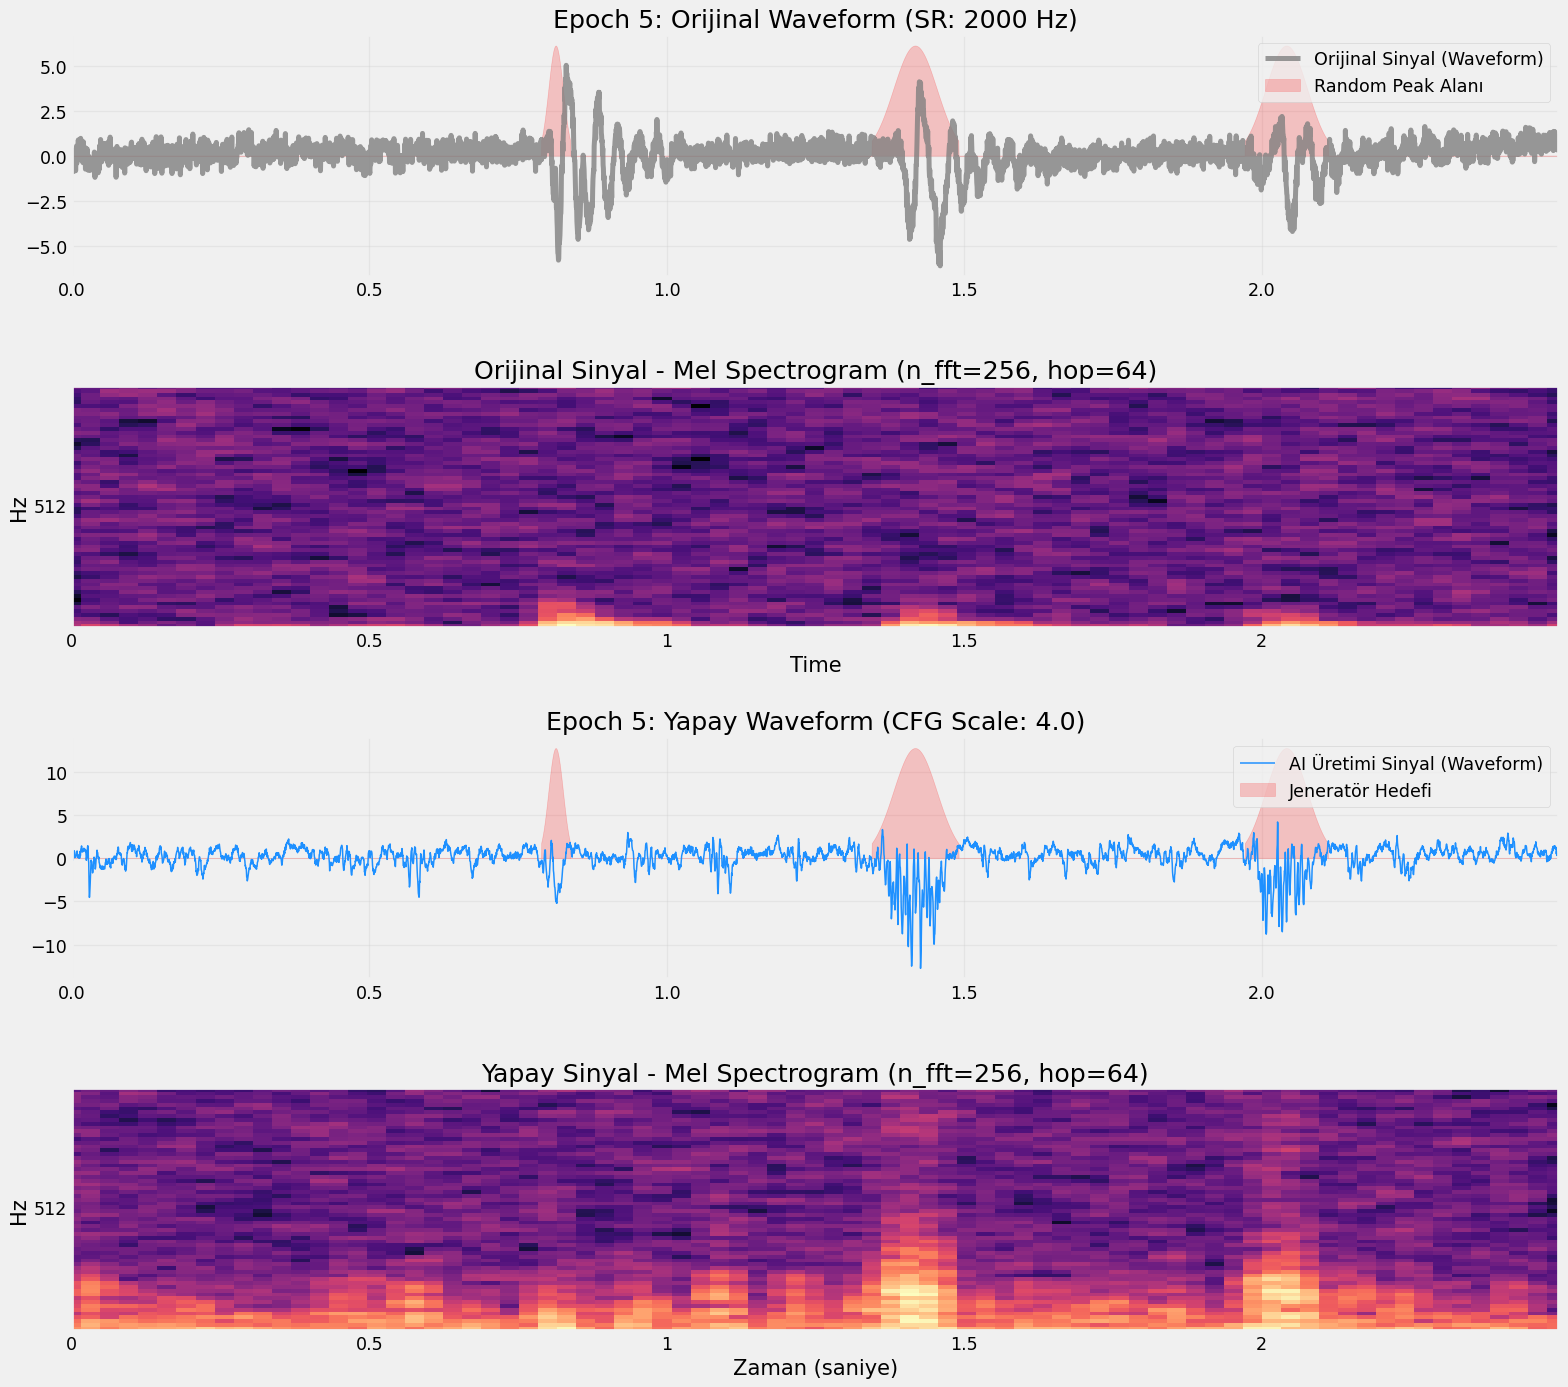

💾 Epoch 5 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 856/856 | Diffusion Loss (MSE): 0.2006
Epoch 6 Özet | Avg Diffusion Loss: 0.1132 | Süre: 176.8 sn
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 856/856 | Diffusion Loss (MSE): 0.1118
Epoch 7 Özet | Avg Diffusion Loss: 0.1115 | Süre: 177.5 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 7 - Loss: 0.1115)
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 856/856 | Diffusion Loss (MSE): 0.0635
Epoch 8 Özet | Avg Diffusion Loss: 0.1125 | Süre: 177.4 sn
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 856/856 | Diffusion Loss (MSE): 0.0184
Epoch 9 Özet | Avg Diffusion Loss: 0.1138 | Süre: 177.5 sn
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 856/856 | Diffusion Loss (MSE): 0.0498
Epoch 10 Özet | Avg Diffusion Loss: 0.1093 | Süre: 177.4 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 10 - Loss: 0.1093)
Epoch 10 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 10 Denoising: 100%|██████████| 1000/1000 [07:51<00:00,  2.12it/s]


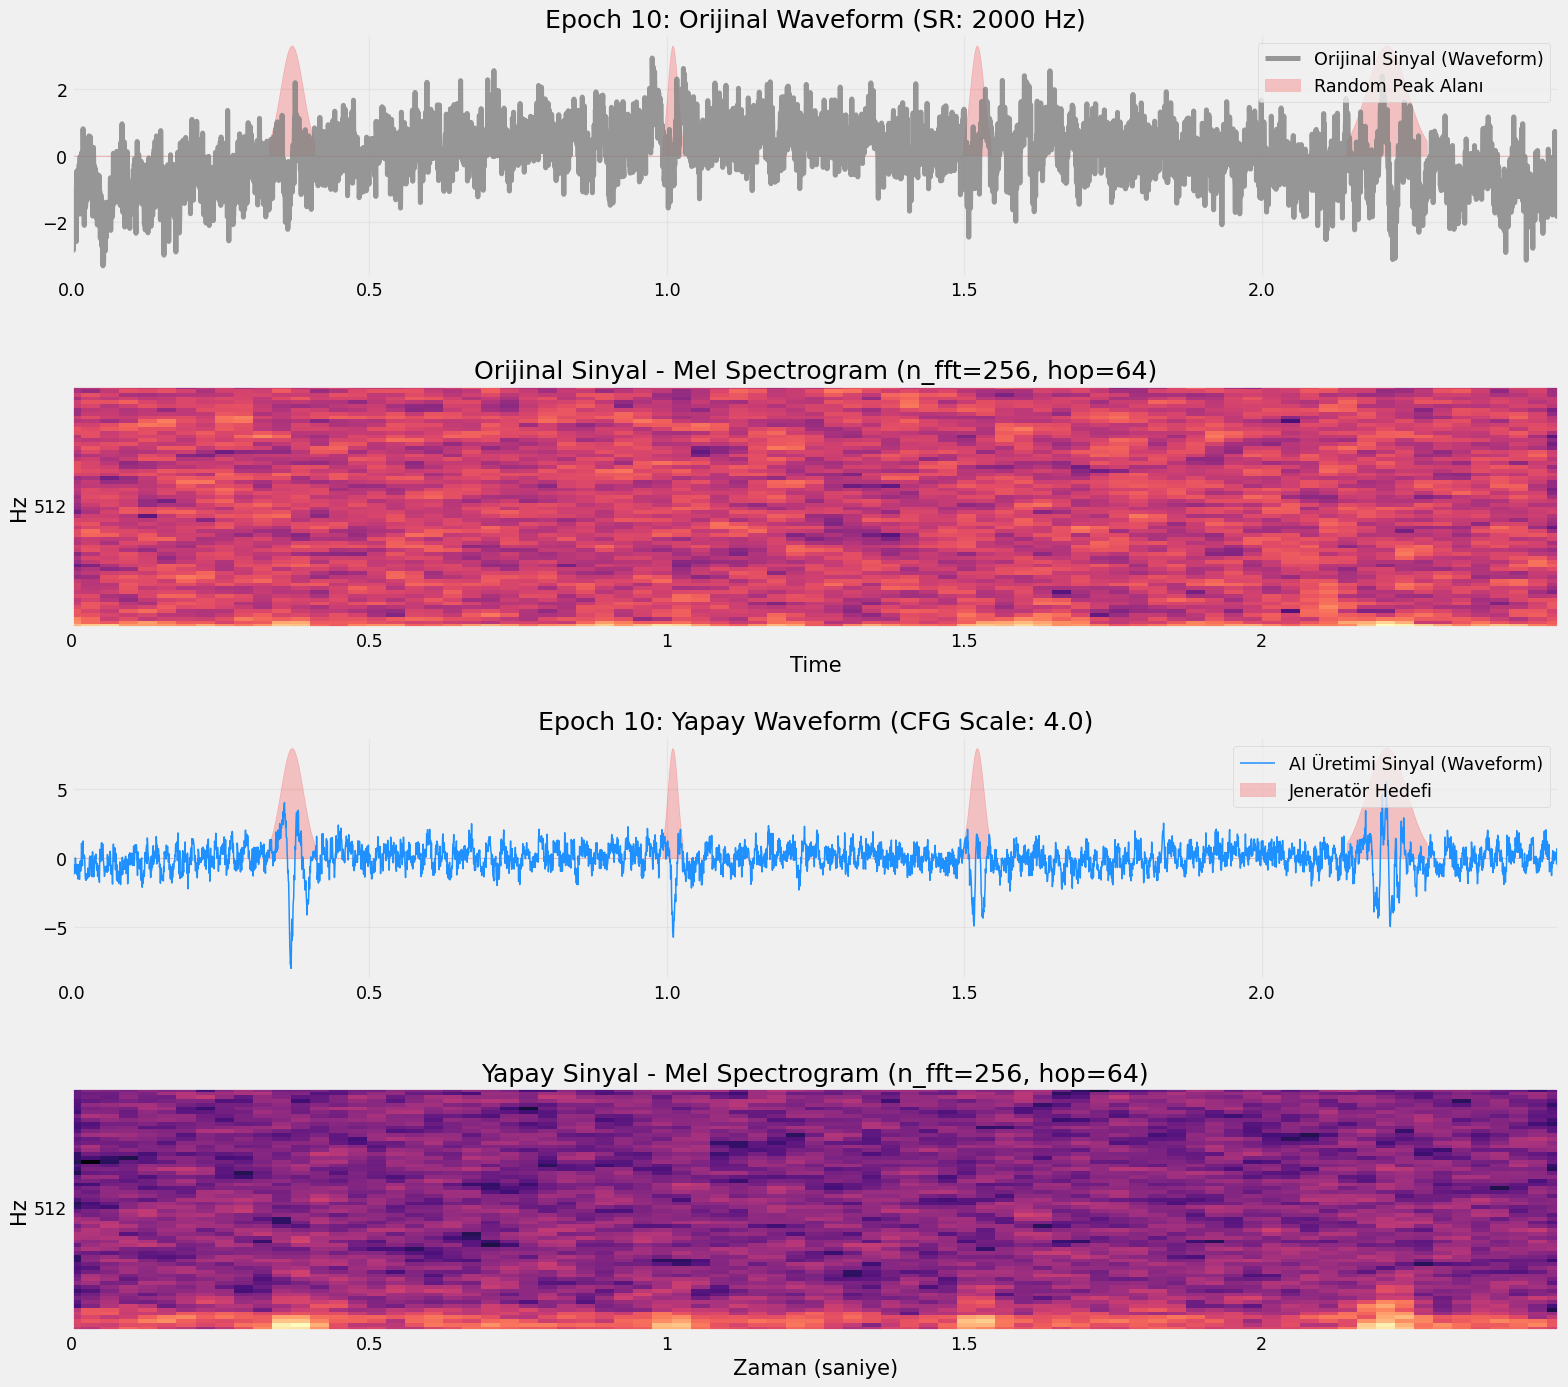

💾 Epoch 10 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 856/856 | Diffusion Loss (MSE): 0.5237
Epoch 11 Özet | Avg Diffusion Loss: 0.1113 | Süre: 176.9 sn
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 856/856 | Diffusion Loss (MSE): 0.0343
Epoch 12 Özet | Avg Diffusion Loss: 0.1133 | Süre: 177.2 sn
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 856/856 | Diffusion Loss (MSE): 0.0279
Epoch 13 Özet | Avg Diffusion Loss: 0.1098 | Süre: 177.5 sn
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 856/856 | Diffusion Loss (MSE): 0.3221
Epoch 14 Özet | Avg Diffusion Loss: 0.1095 | Süre: 177.5 sn
--- EPOCH 15 BAŞLADI ---
Epoch 15 | Step 856/856 | Diffusion Loss (MSE): 0.0529
Epoch 15 Özet | Avg Diffusion Loss: 0.1072 | Süre: 177.6 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 15 - Loss: 0.1072)
Epoch 15 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 15 Denoising: 100%|██████████| 1000/1000 [07:51<00:00,  2.12it/s]


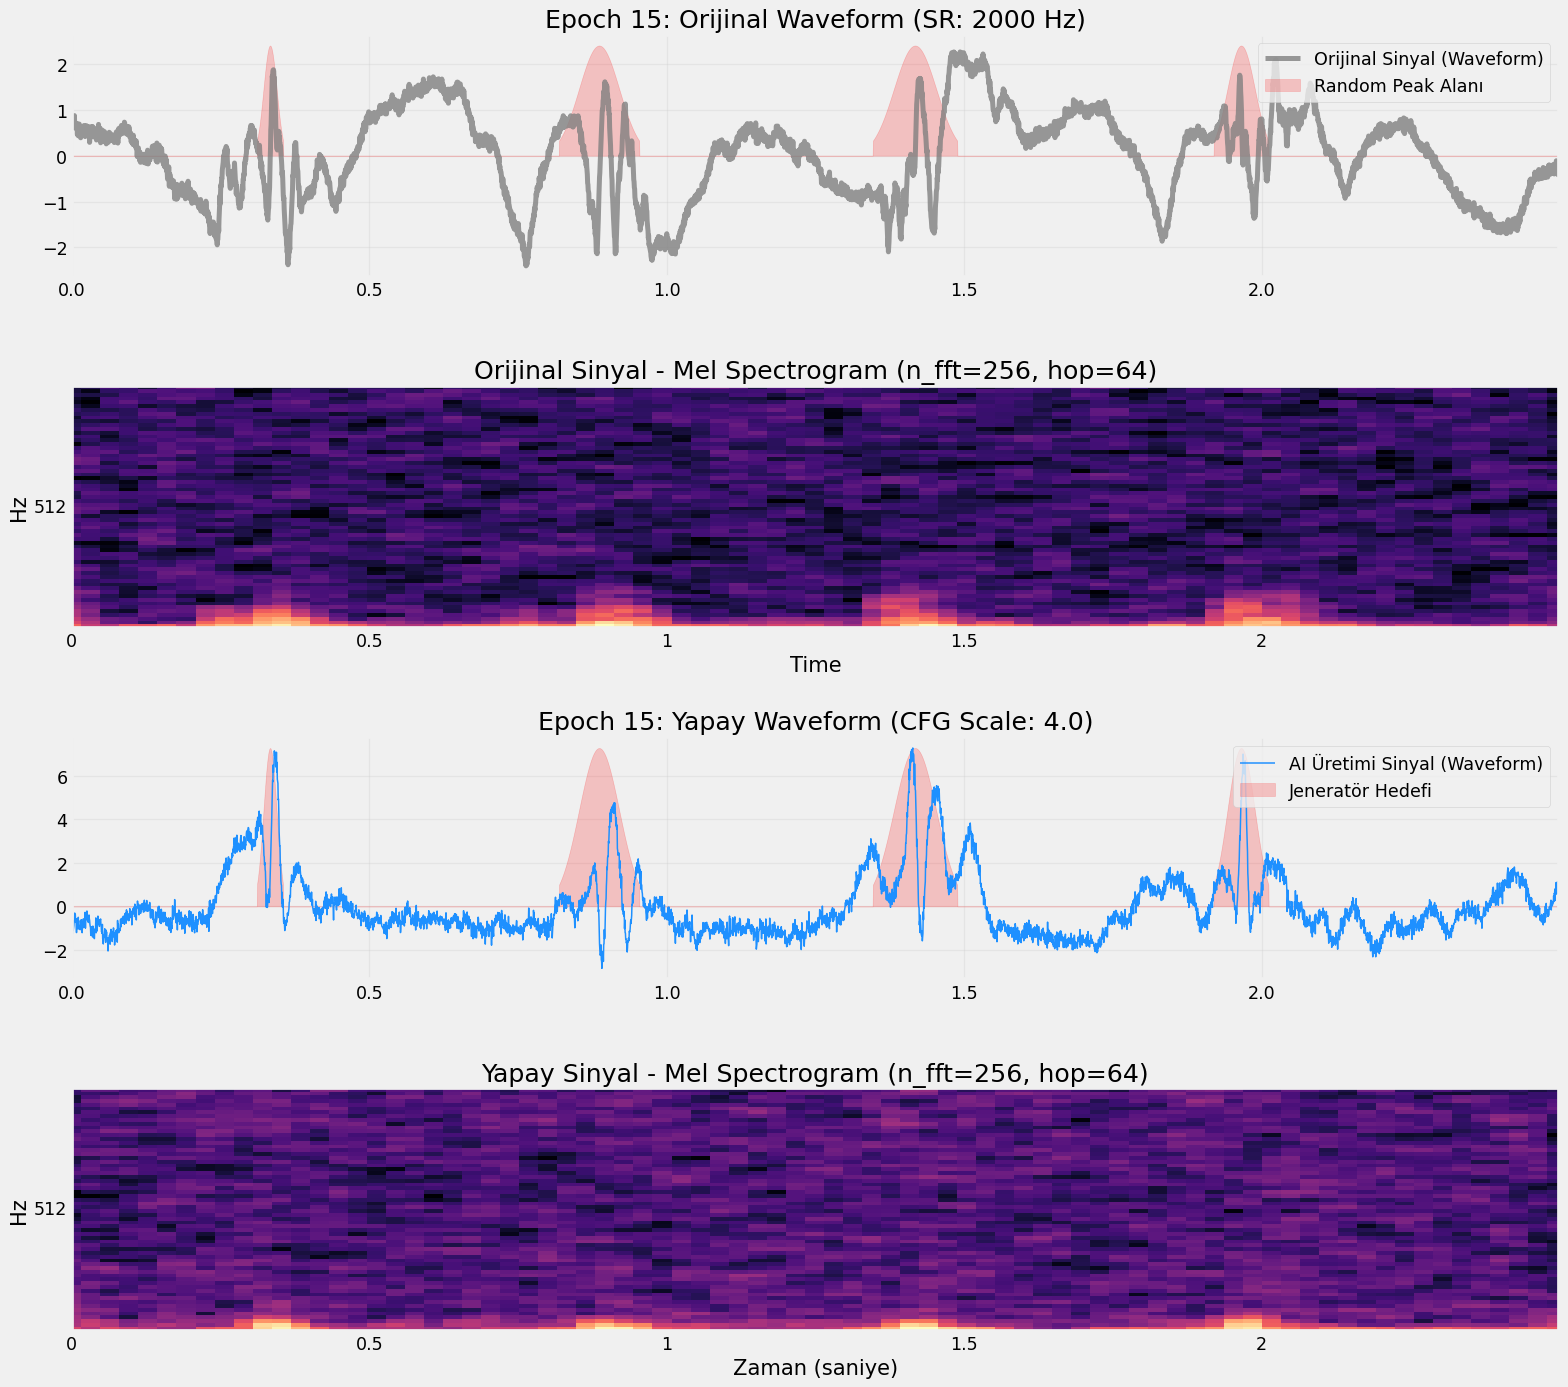

💾 Epoch 15 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 856/856 | Diffusion Loss (MSE): 0.5243
Epoch 16 Özet | Avg Diffusion Loss: 0.1113 | Süre: 177.0 sn
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 856/856 | Diffusion Loss (MSE): 0.1605
Epoch 17 Özet | Avg Diffusion Loss: 0.1069 | Süre: 177.7 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 17 - Loss: 0.1069)
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 856/856 | Diffusion Loss (MSE): 0.2118
Epoch 18 Özet | Avg Diffusion Loss: 0.1101 | Süre: 177.5 sn
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 856/856 | Diffusion Loss (MSE): 0.3506
Epoch 19 Özet | Avg Diffusion Loss: 0.1106 | Süre: 177.8 sn
--- EPOCH 20 BAŞLADI ---
Epoch 20 | Step 856/856 | Diffusion Loss (MSE): 0.4225
Epoch 20 Özet | Avg Diffusion Loss: 0.1094 | Süre: 177.9 sn
Epoch 20 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 20 Denoising: 100%|██████████| 1000/1000 [07:42<00:00,  2.16it/s]


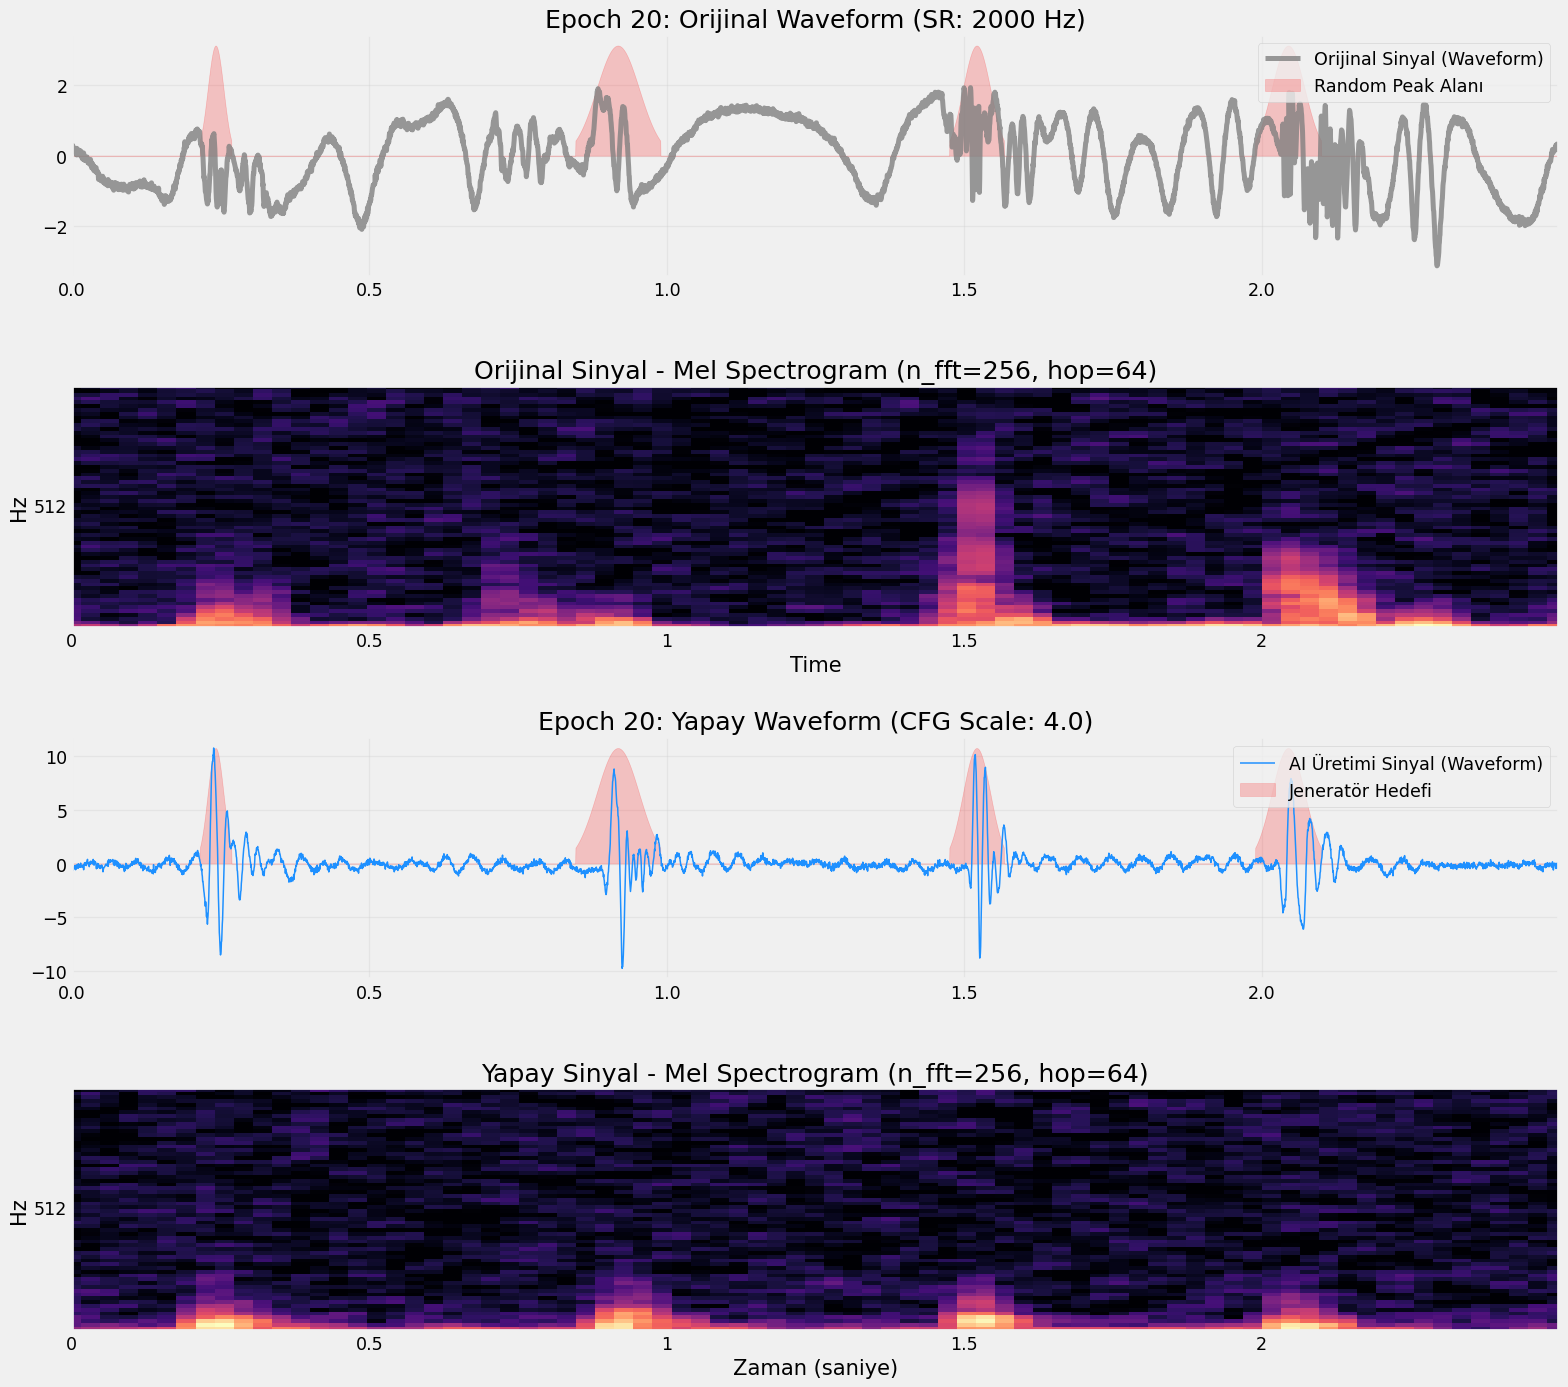

💾 Epoch 20 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 856/856 | Diffusion Loss (MSE): 0.1473
Epoch 21 Özet | Avg Diffusion Loss: 0.1077 | Süre: 177.1 sn
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 856/856 | Diffusion Loss (MSE): 0.0143
Epoch 22 Özet | Avg Diffusion Loss: 0.1083 | Süre: 178.1 sn
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 856/856 | Diffusion Loss (MSE): 0.1832
Epoch 23 Özet | Avg Diffusion Loss: 0.1091 | Süre: 177.2 sn
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 856/856 | Diffusion Loss (MSE): 0.0922
Epoch 24 Özet | Avg Diffusion Loss: 0.1076 | Süre: 178.2 sn
--- EPOCH 25 BAŞLADI ---
Epoch 25 | Step 856/856 | Diffusion Loss (MSE): 0.6887
Epoch 25 Özet | Avg Diffusion Loss: 0.1090 | Süre: 177.9 sn
Epoch 25 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 25 Denoising: 100%|██████████| 1000/1000 [07:46<00:00,  2.14it/s]


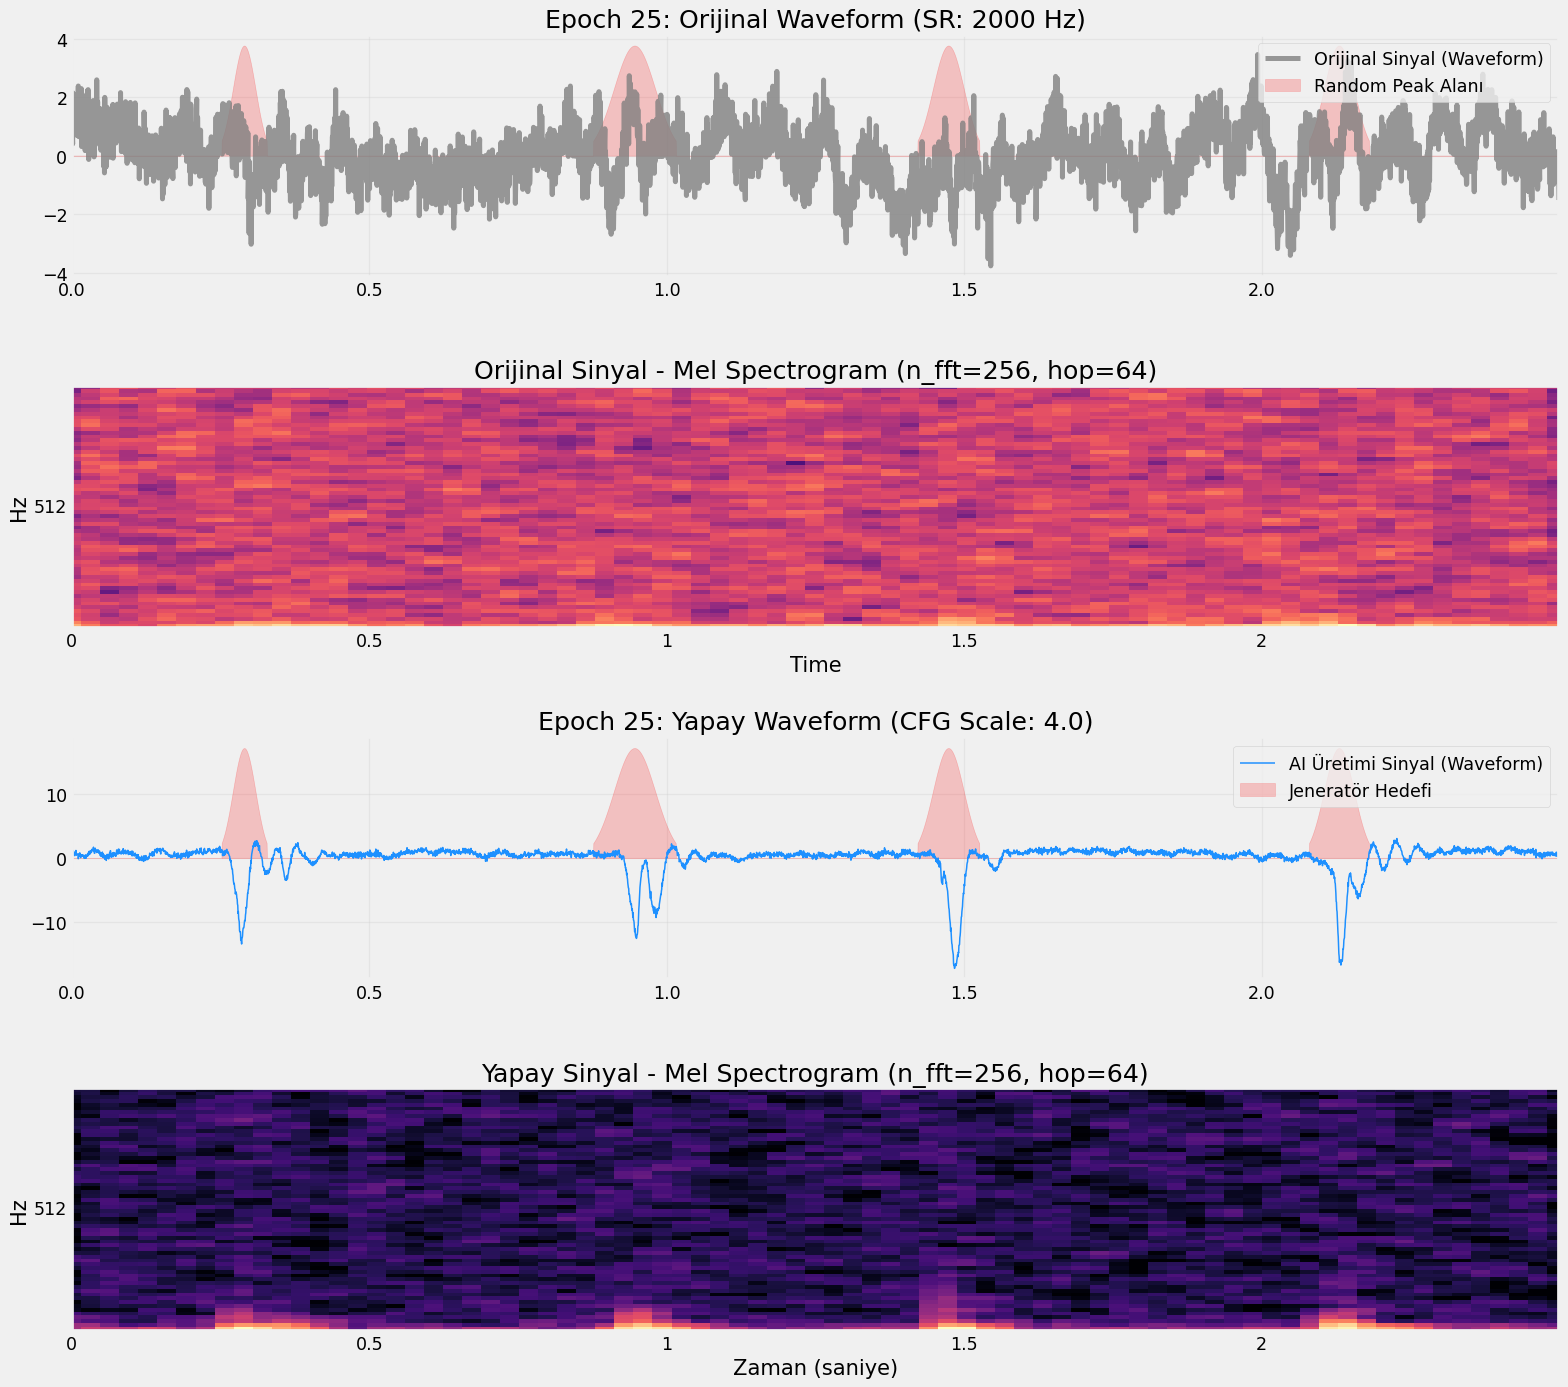

💾 Epoch 25 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 856/856 | Diffusion Loss (MSE): 0.2735
Epoch 26 Özet | Avg Diffusion Loss: 0.1042 | Süre: 177.3 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 26 - Loss: 0.1042)
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 856/856 | Diffusion Loss (MSE): 0.3883
Epoch 27 Özet | Avg Diffusion Loss: 0.1082 | Süre: 177.8 sn
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 856/856 | Diffusion Loss (MSE): 0.0280
Epoch 28 Özet | Avg Diffusion Loss: 0.1072 | Süre: 178.4 sn
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 856/856 | Diffusion Loss (MSE): 0.0015
Epoch 29 Özet | Avg Diffusion Loss: 0.1048 | Süre: 177.6 sn
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 856/856 | Diffusion Loss (MSE): 0.1072
Epoch 30 Özet | Avg Diffusion Loss: 0.1124 | Süre: 177.7 sn
Epoch 30 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 30 Denoising: 100%|██████████| 1000/1000 [07:47<00:00,  2.14it/s]


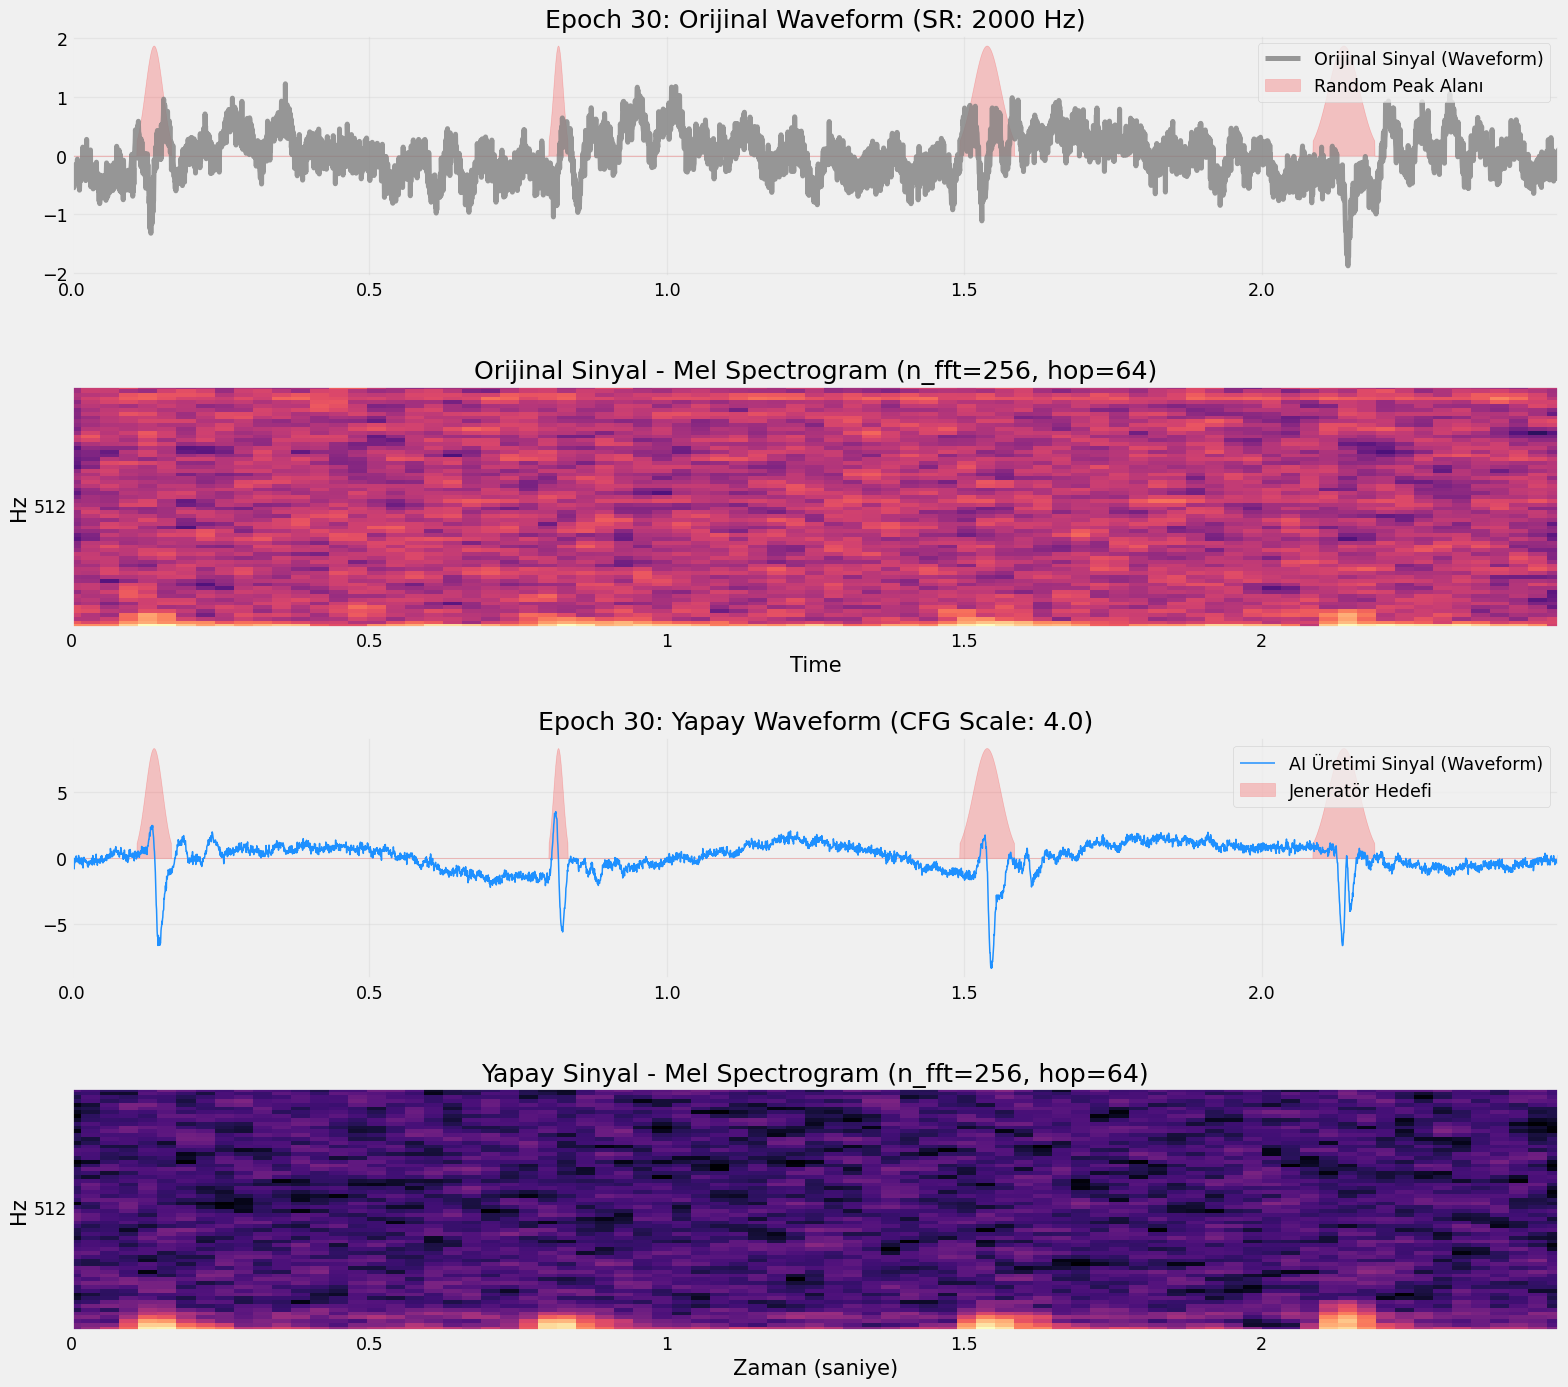

💾 Epoch 30 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 856/856 | Diffusion Loss (MSE): 0.0238
Epoch 31 Özet | Avg Diffusion Loss: 0.1083 | Süre: 177.5 sn
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 856/856 | Diffusion Loss (MSE): 0.3124
Epoch 32 Özet | Avg Diffusion Loss: 0.1085 | Süre: 190.7 sn
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 856/856 | Diffusion Loss (MSE): 0.3407
Epoch 33 Özet | Avg Diffusion Loss: 0.1069 | Süre: 185.6 sn
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 856/856 | Diffusion Loss (MSE): 0.0119
Epoch 34 Özet | Avg Diffusion Loss: 0.1069 | Süre: 177.5 sn
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 856/856 | Diffusion Loss (MSE): 0.0071
Epoch 35 Özet | Avg Diffusion Loss: 0.1072 | Süre: 177.9 sn
Epoch 35 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 35 Denoising: 100%|██████████| 1000/1000 [07:47<00:00,  2.14it/s]


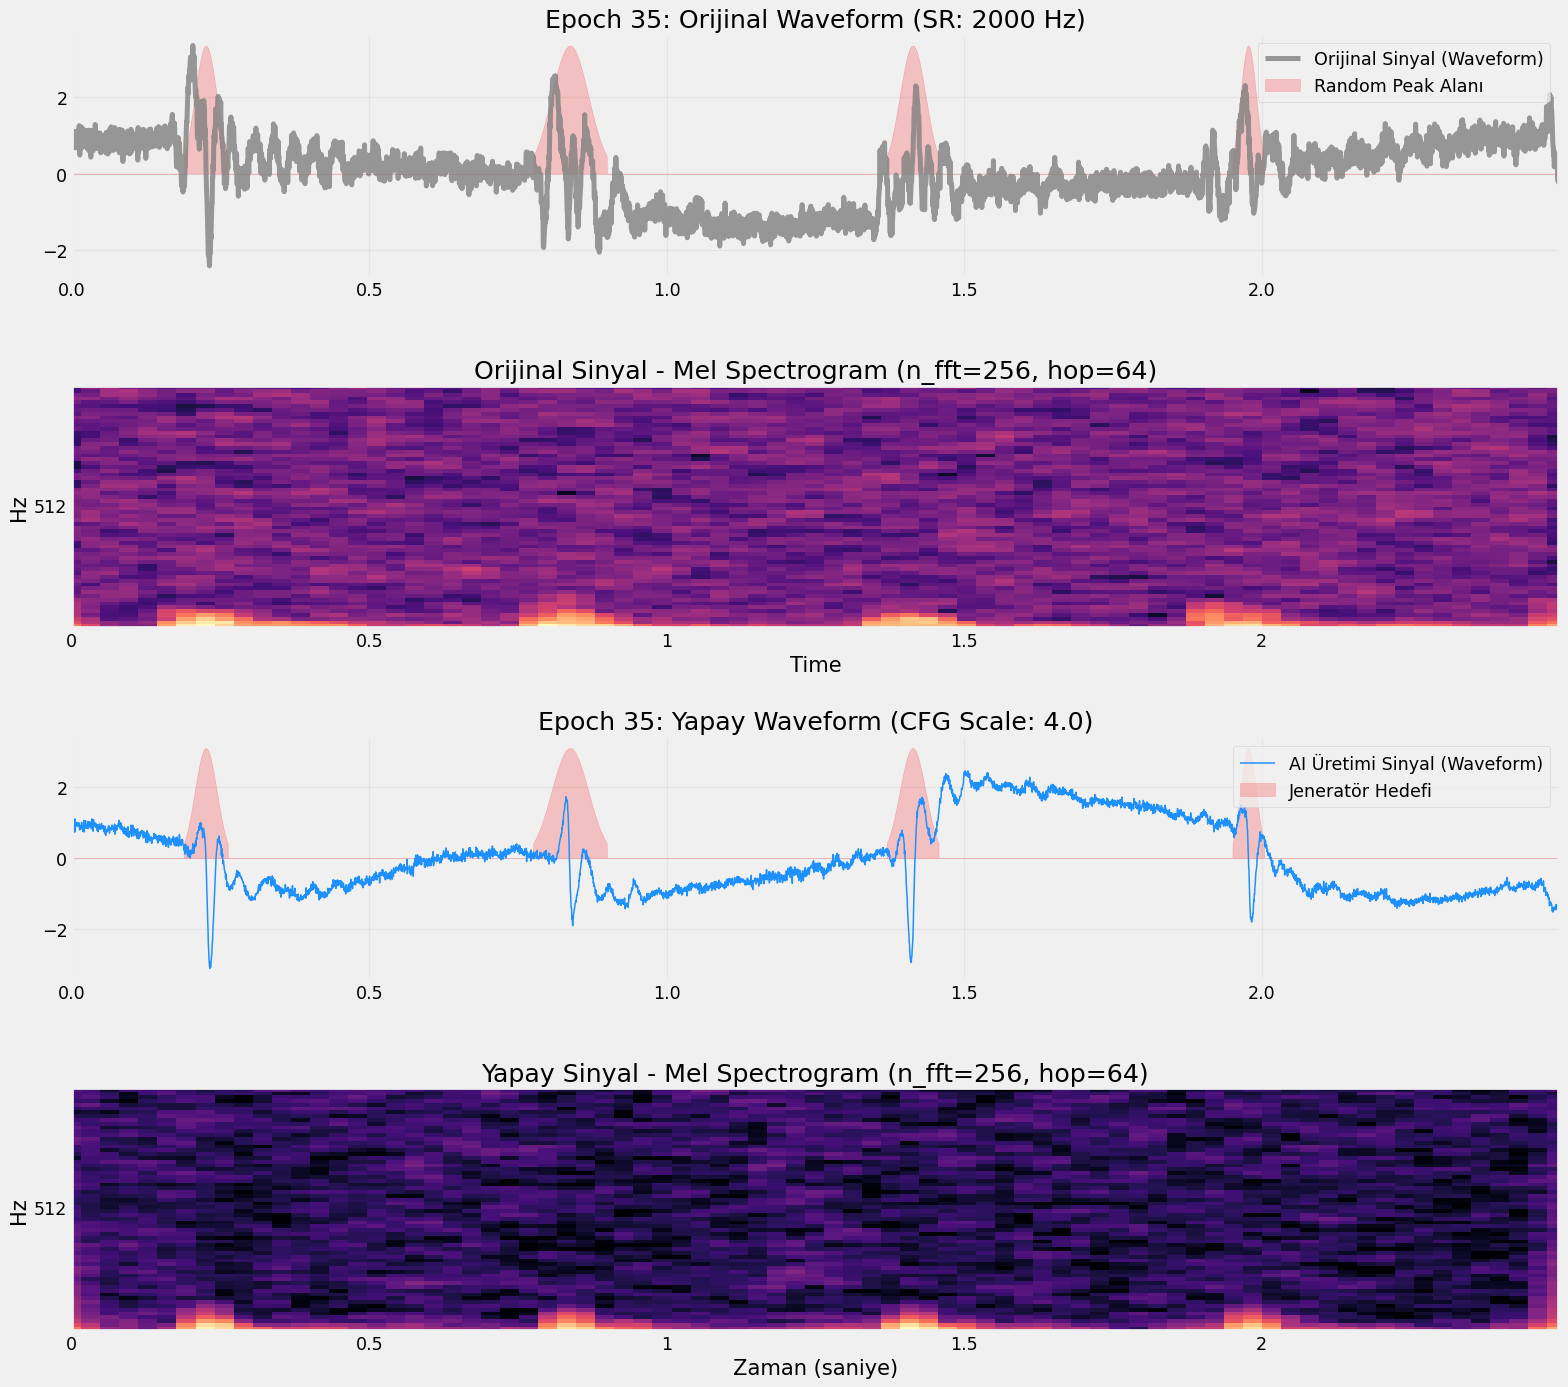

💾 Epoch 35 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 36 BAŞLADI ---
Epoch 36 | Step 856/856 | Diffusion Loss (MSE): 0.0300
Epoch 36 Özet | Avg Diffusion Loss: 0.1062 | Süre: 194.0 sn
--- EPOCH 37 BAŞLADI ---
Epoch 37 | Step 856/856 | Diffusion Loss (MSE): 0.0092
Epoch 37 Özet | Avg Diffusion Loss: 0.1067 | Süre: 181.6 sn
--- EPOCH 38 BAŞLADI ---
Epoch 38 | Step 856/856 | Diffusion Loss (MSE): 0.0066
Epoch 38 Özet | Avg Diffusion Loss: 0.1097 | Süre: 177.5 sn
--- EPOCH 39 BAŞLADI ---
Epoch 39 | Step 856/856 | Diffusion Loss (MSE): 0.0599
Epoch 39 Özet | Avg Diffusion Loss: 0.1066 | Süre: 177.4 sn
--- EPOCH 40 BAŞLADI ---
Epoch 40 | Step 856/856 | Diffusion Loss (MSE): 0.0779
Epoch 40 Özet | Avg Diffusion Loss: 0.1098 | Süre: 177.5 sn
Epoch 40 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 40 Denoising: 100%|██████████| 1000/1000 [07:45<00:00,  2.15it/s]


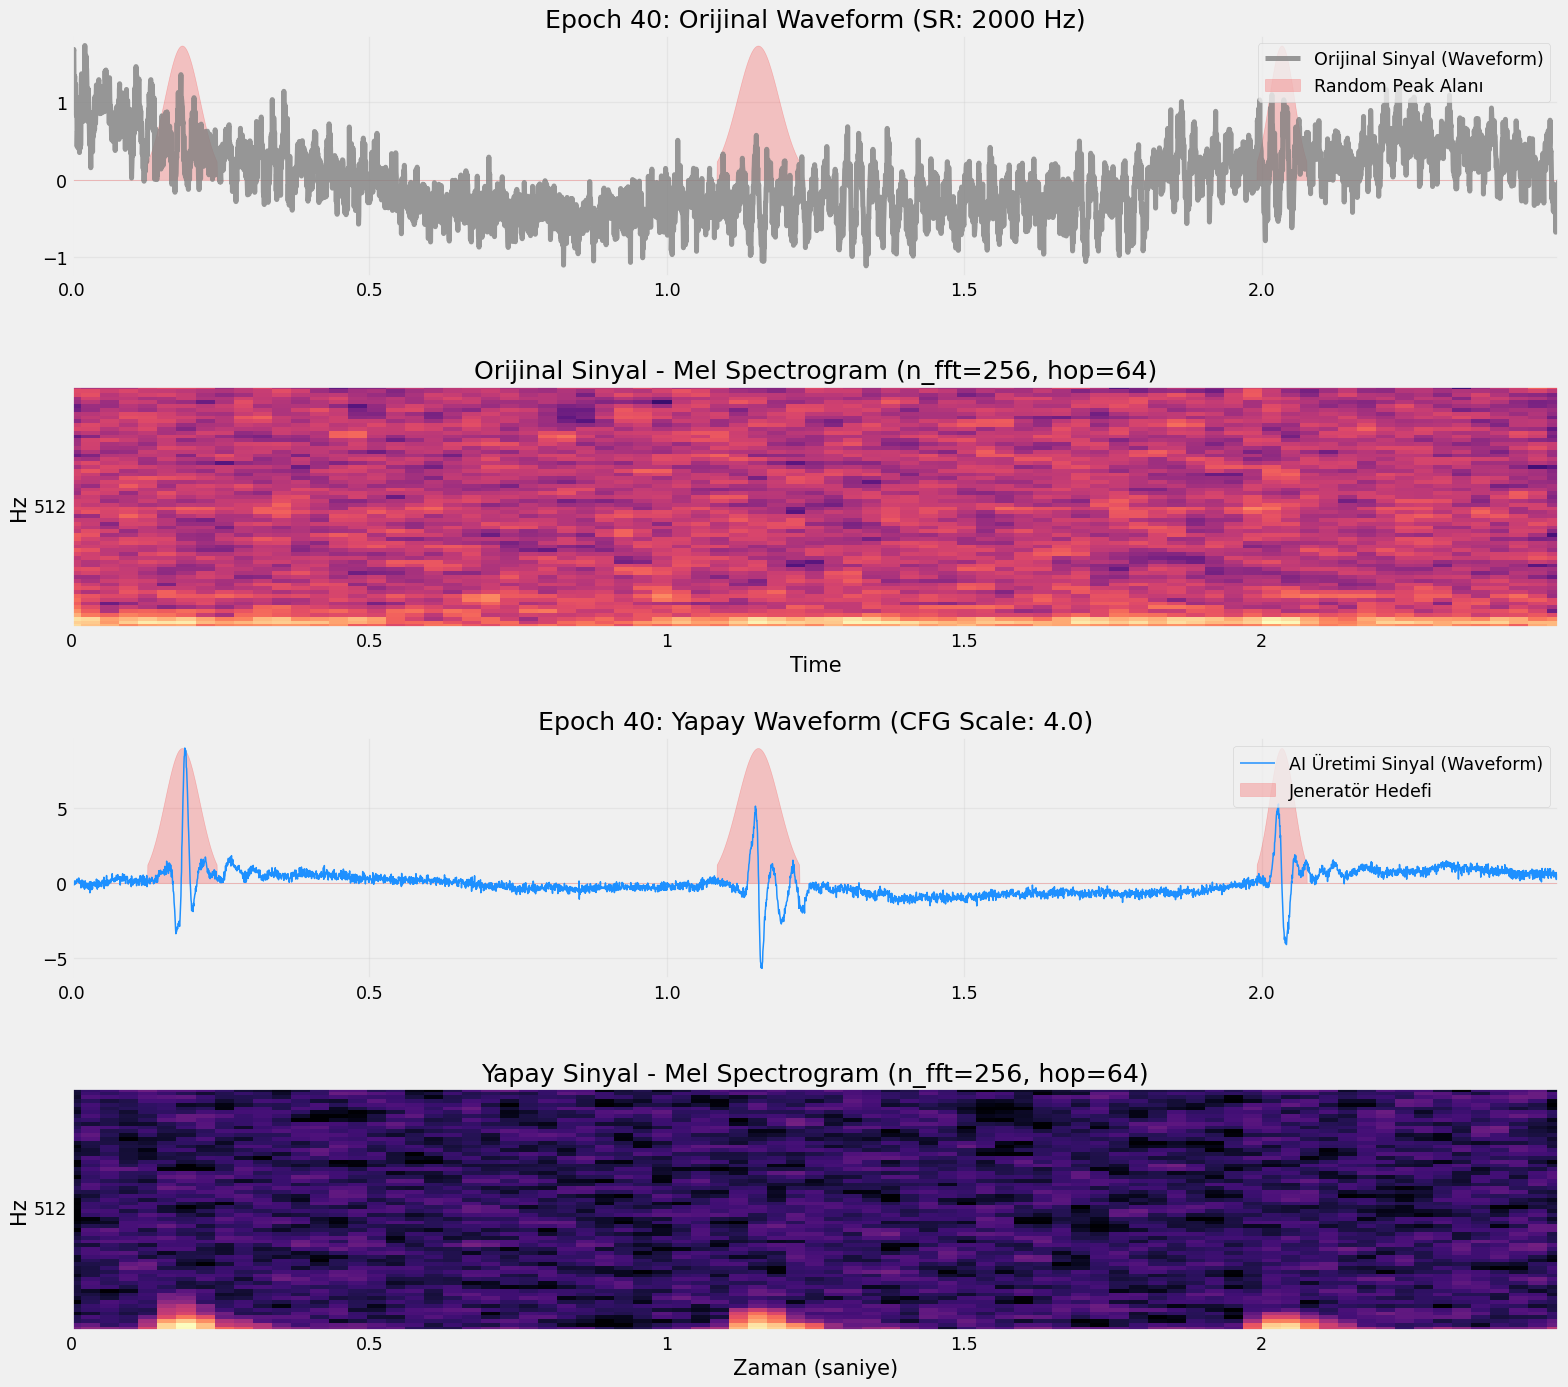

💾 Epoch 40 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 41 BAŞLADI ---
Epoch 41 | Step 856/856 | Diffusion Loss (MSE): 0.4837
Epoch 41 Özet | Avg Diffusion Loss: 0.1085 | Süre: 177.3 sn
--- EPOCH 42 BAŞLADI ---
Epoch 42 | Step 856/856 | Diffusion Loss (MSE): 0.0012
Epoch 42 Özet | Avg Diffusion Loss: 0.1060 | Süre: 177.5 sn
--- EPOCH 43 BAŞLADI ---
Epoch 43 | Step 856/856 | Diffusion Loss (MSE): 0.0118
Epoch 43 Özet | Avg Diffusion Loss: 0.1041 | Süre: 177.6 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 43 - Loss: 0.1041)
--- EPOCH 44 BAŞLADI ---
Epoch 44 | Step 856/856 | Diffusion Loss (MSE): 0.0743
Epoch 44 Özet | Avg Diffusion Loss: 0.1087 | Süre: 177.4 sn
--- EPOCH 45 BAŞLADI ---
Epoch 45 | Step 856/856 | Diffusion Loss (MSE): 0.0218
Epoch 45 Özet | Avg Diffusion Loss: 0.1056 | Süre: 177.4 sn
Epoch 45 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 45 Denoising: 100%|██████████| 1000/1000 [07:45<00:00,  2.15it/s]


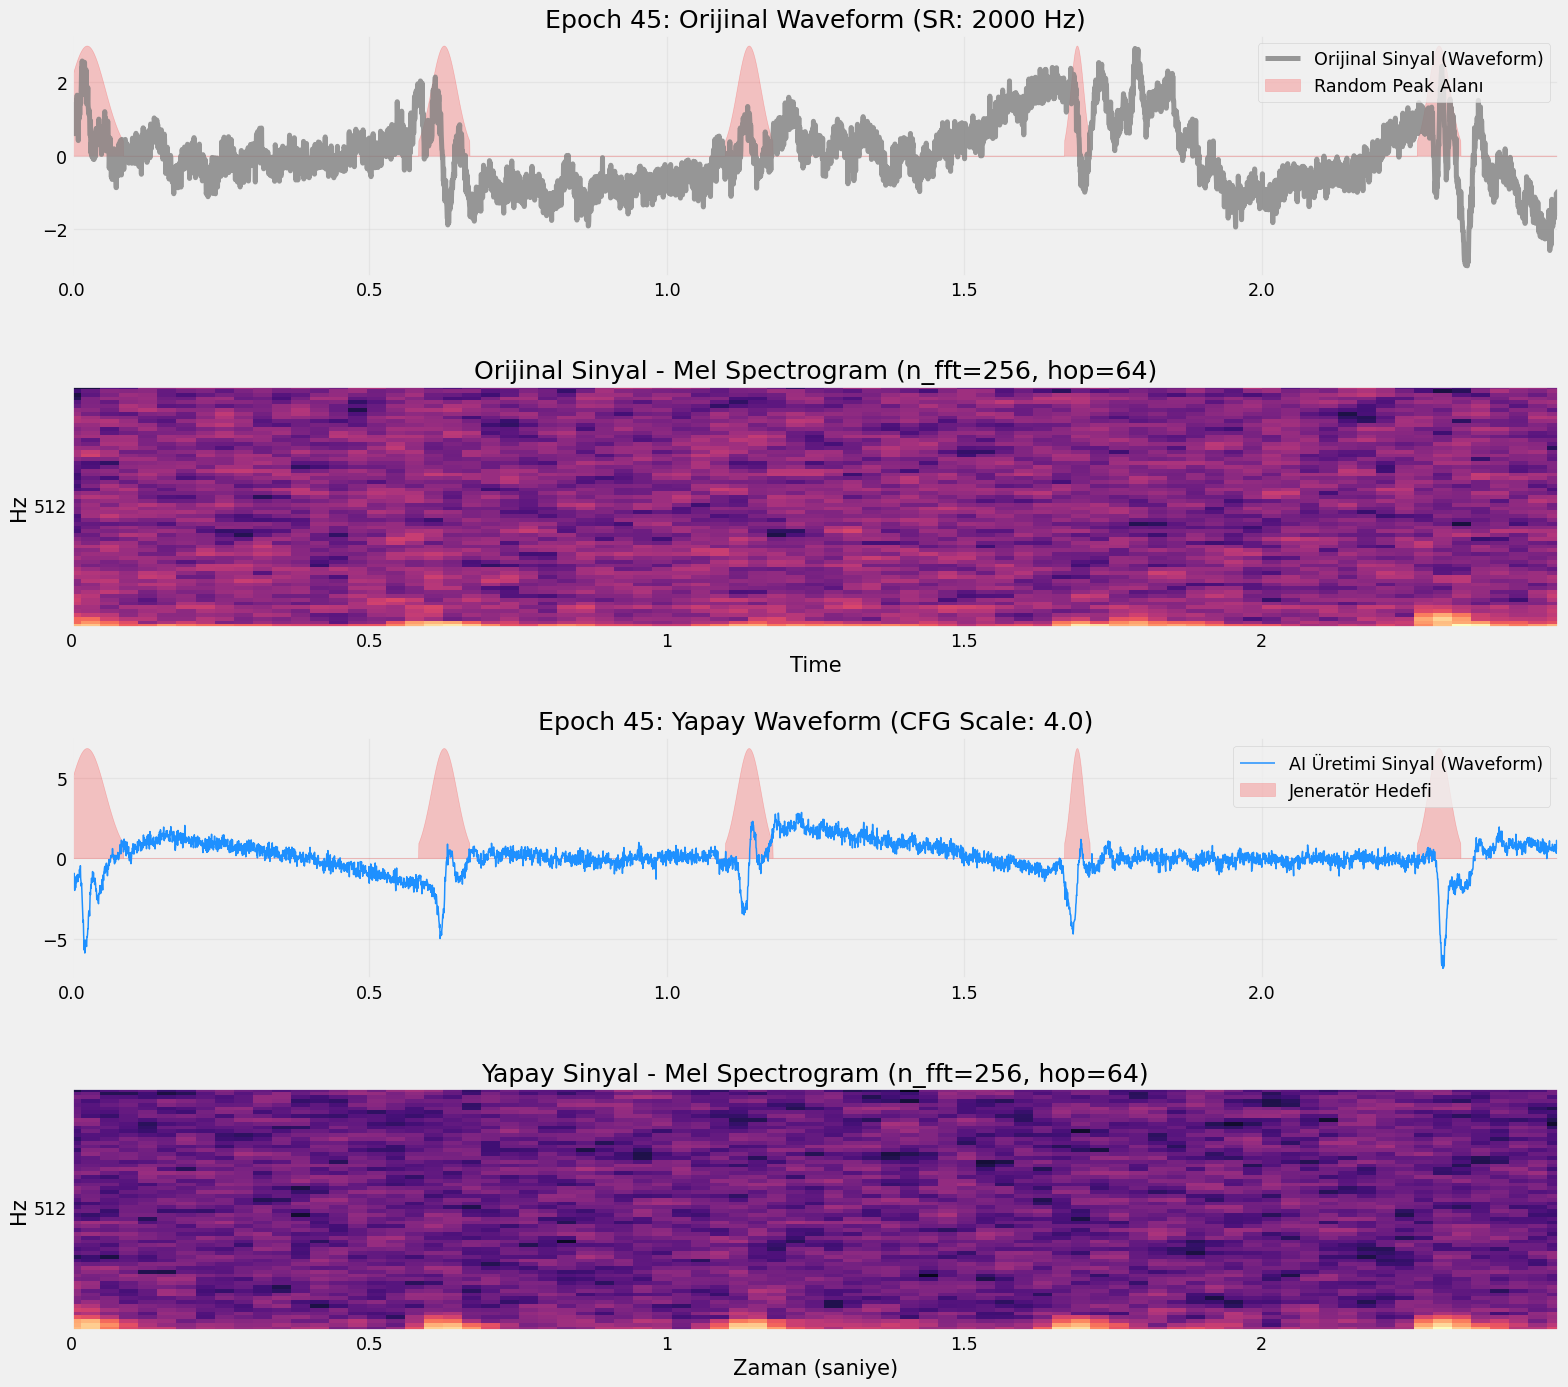

💾 Epoch 45 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 46 BAŞLADI ---
Epoch 46 | Step 856/856 | Diffusion Loss (MSE): 0.6229
Epoch 46 Özet | Avg Diffusion Loss: 0.1100 | Süre: 177.0 sn
--- EPOCH 47 BAŞLADI ---
Epoch 47 | Step 856/856 | Diffusion Loss (MSE): 0.1621
Epoch 47 Özet | Avg Diffusion Loss: 0.1080 | Süre: 177.3 sn
--- EPOCH 48 BAŞLADI ---
Epoch 48 | Step 856/856 | Diffusion Loss (MSE): 0.1046
Epoch 48 Özet | Avg Diffusion Loss: 0.1060 | Süre: 177.4 sn
--- EPOCH 49 BAŞLADI ---
Epoch 49 | Step 856/856 | Diffusion Loss (MSE): 0.0550
Epoch 49 Özet | Avg Diffusion Loss: 0.1082 | Süre: 177.7 sn
--- EPOCH 50 BAŞLADI ---
Epoch 50 | Step 856/856 | Diffusion Loss (MSE): 0.3108
Epoch 50 Özet | Avg Diffusion Loss: 0.1066 | Süre: 177.7 sn
Epoch 50 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 50 Denoising: 100%|██████████| 1000/1000 [07:55<00:00,  2.10it/s]


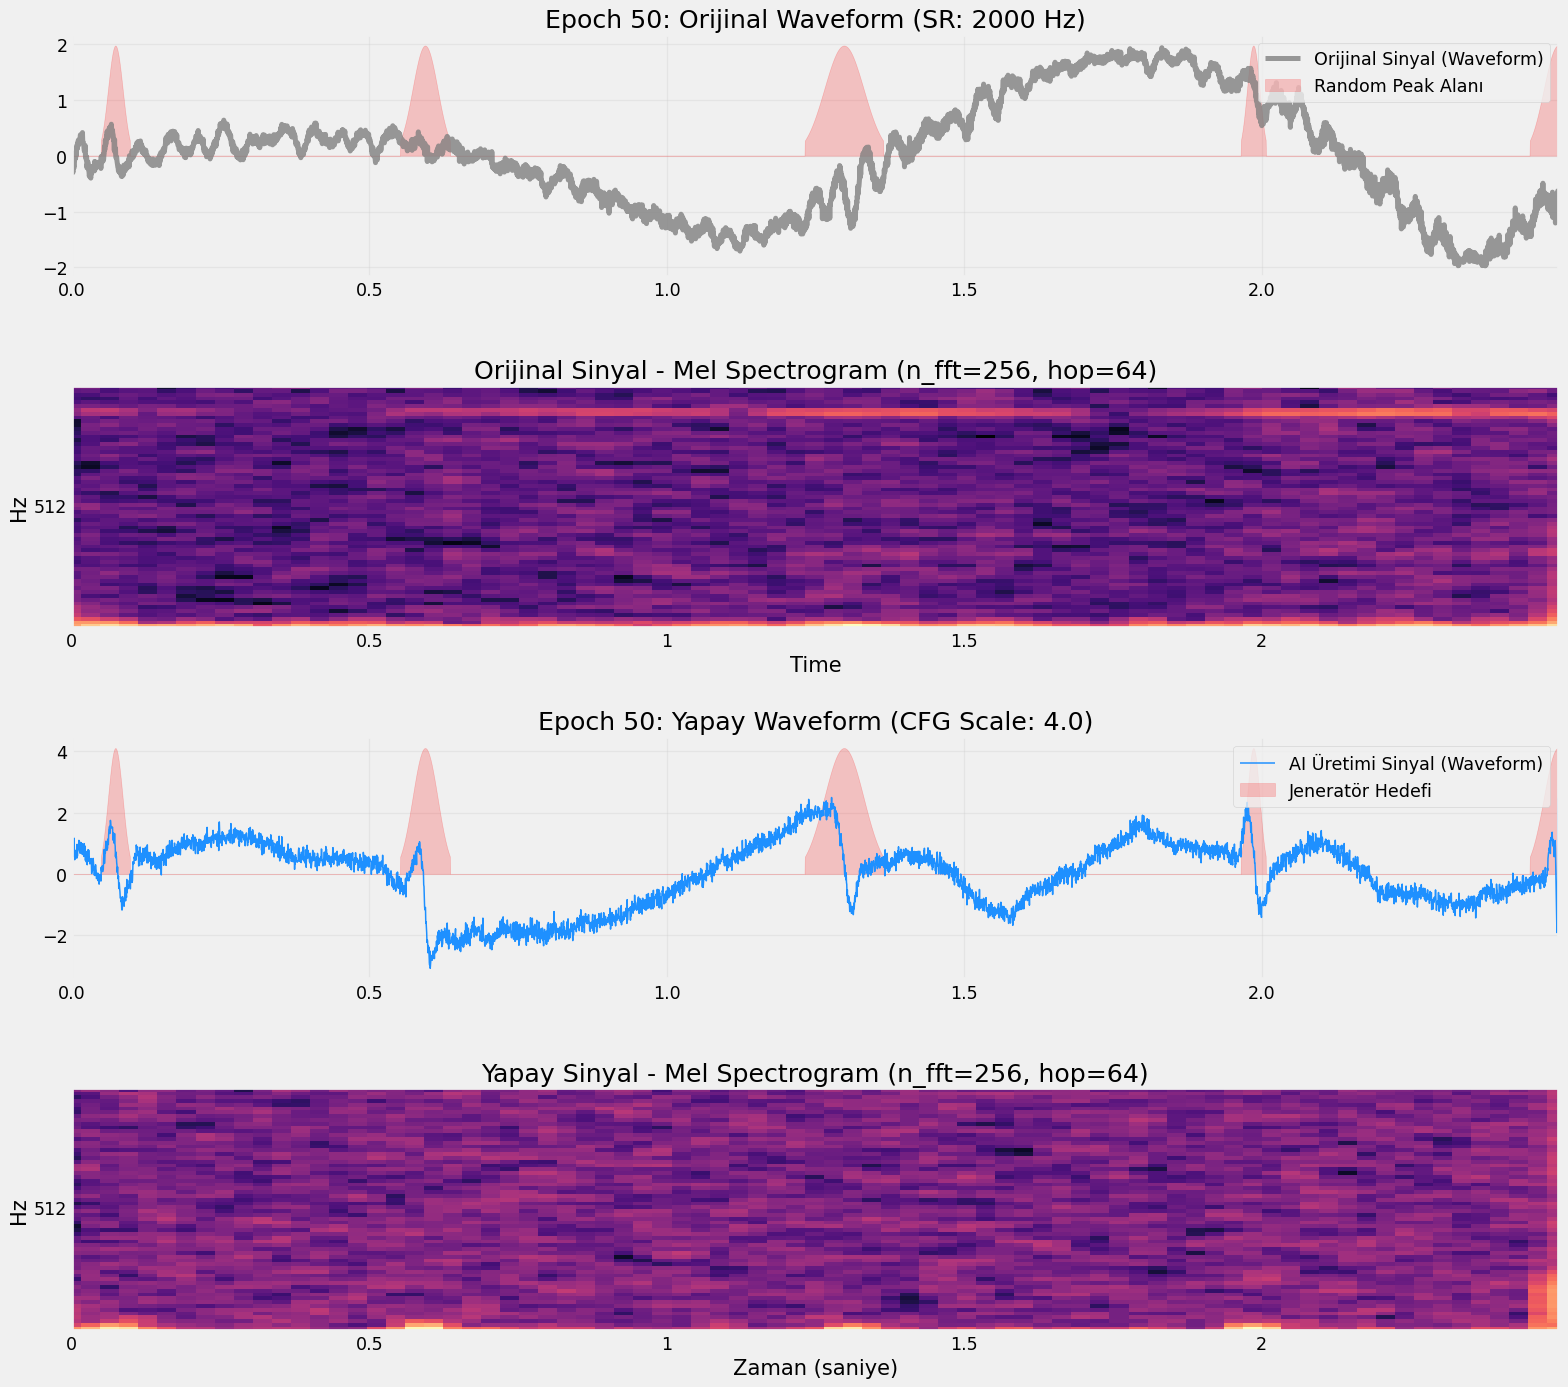

💾 Epoch 50 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 51 BAŞLADI ---
Epoch 51 | Step 856/856 | Diffusion Loss (MSE): 0.7459
Epoch 51 Özet | Avg Diffusion Loss: 0.1101 | Süre: 178.4 sn
--- EPOCH 52 BAŞLADI ---
Epoch 52 | Step 856/856 | Diffusion Loss (MSE): 0.1600
Epoch 52 Özet | Avg Diffusion Loss: 0.1097 | Süre: 194.4 sn
--- EPOCH 53 BAŞLADI ---
Epoch 53 | Step 856/856 | Diffusion Loss (MSE): 0.1159
Epoch 53 Özet | Avg Diffusion Loss: 0.1105 | Süre: 179.4 sn
--- EPOCH 54 BAŞLADI ---
Epoch 54 | Step 856/856 | Diffusion Loss (MSE): 0.0106
Epoch 54 Özet | Avg Diffusion Loss: 0.1075 | Süre: 178.1 sn
--- EPOCH 55 BAŞLADI ---
Epoch 55 | Step 856/856 | Diffusion Loss (MSE): 0.0041
Epoch 55 Özet | Avg Diffusion Loss: 0.1089 | Süre: 177.5 sn
Epoch 55 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 55 Denoising: 100%|██████████| 1000/1000 [07:46<00:00,  2.14it/s]


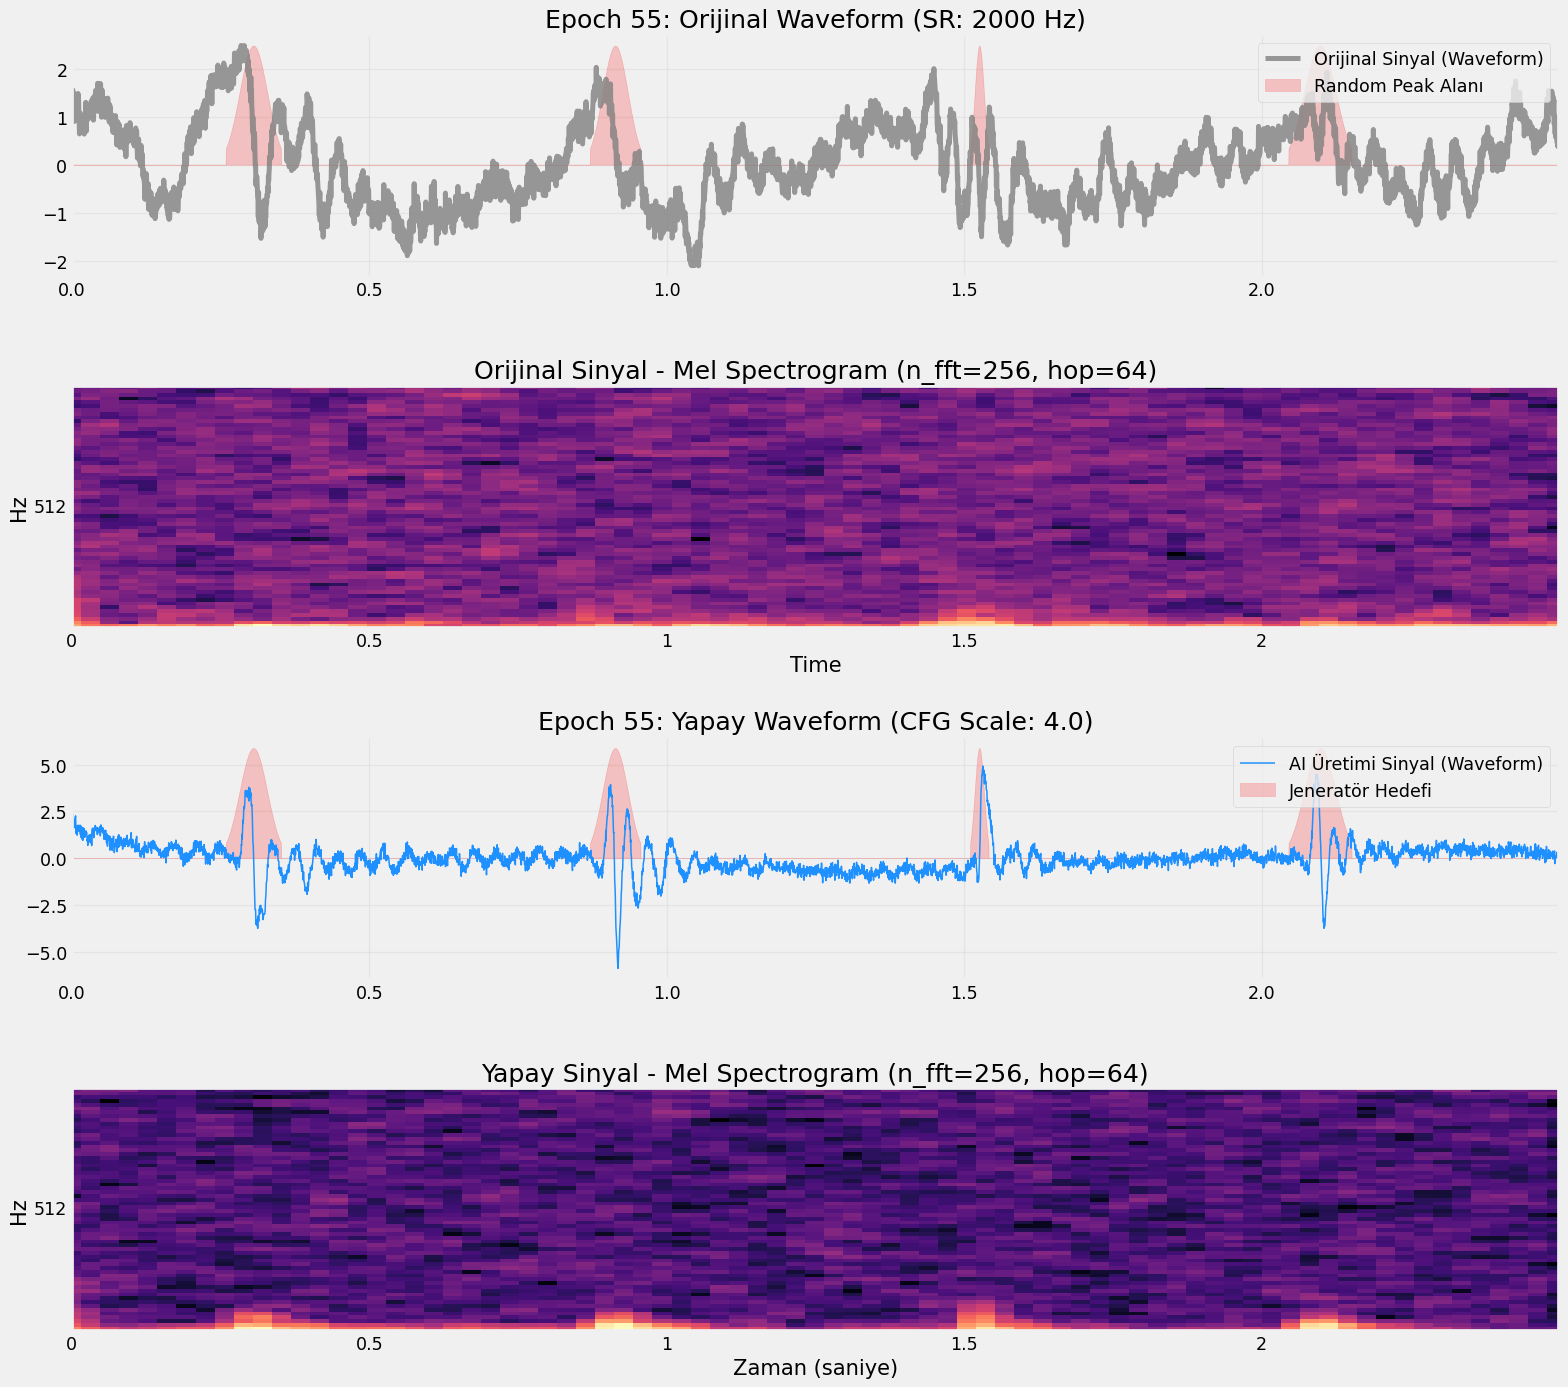

💾 Epoch 55 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 56 BAŞLADI ---
Epoch 56 | Step 856/856 | Diffusion Loss (MSE): 0.1718
Epoch 56 Özet | Avg Diffusion Loss: 0.1056 | Süre: 192.9 sn
--- EPOCH 57 BAŞLADI ---
Epoch 57 | Step 856/856 | Diffusion Loss (MSE): 0.3714
Epoch 57 Özet | Avg Diffusion Loss: 0.1071 | Süre: 183.0 sn
--- EPOCH 58 BAŞLADI ---
Epoch 58 | Step 856/856 | Diffusion Loss (MSE): 0.0505
Epoch 58 Özet | Avg Diffusion Loss: 0.1053 | Süre: 177.4 sn
--- EPOCH 59 BAŞLADI ---
Epoch 59 | Step 856/856 | Diffusion Loss (MSE): 0.3238
Epoch 59 Özet | Avg Diffusion Loss: 0.1048 | Süre: 193.4 sn
--- EPOCH 60 BAŞLADI ---
Epoch 60 | Step 856/856 | Diffusion Loss (MSE): 0.4141
Epoch 60 Özet | Avg Diffusion Loss: 0.1076 | Süre: 183.2 sn
Epoch 60 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 60 Denoising: 100%|██████████| 1000/1000 [07:56<00:00,  2.10it/s]


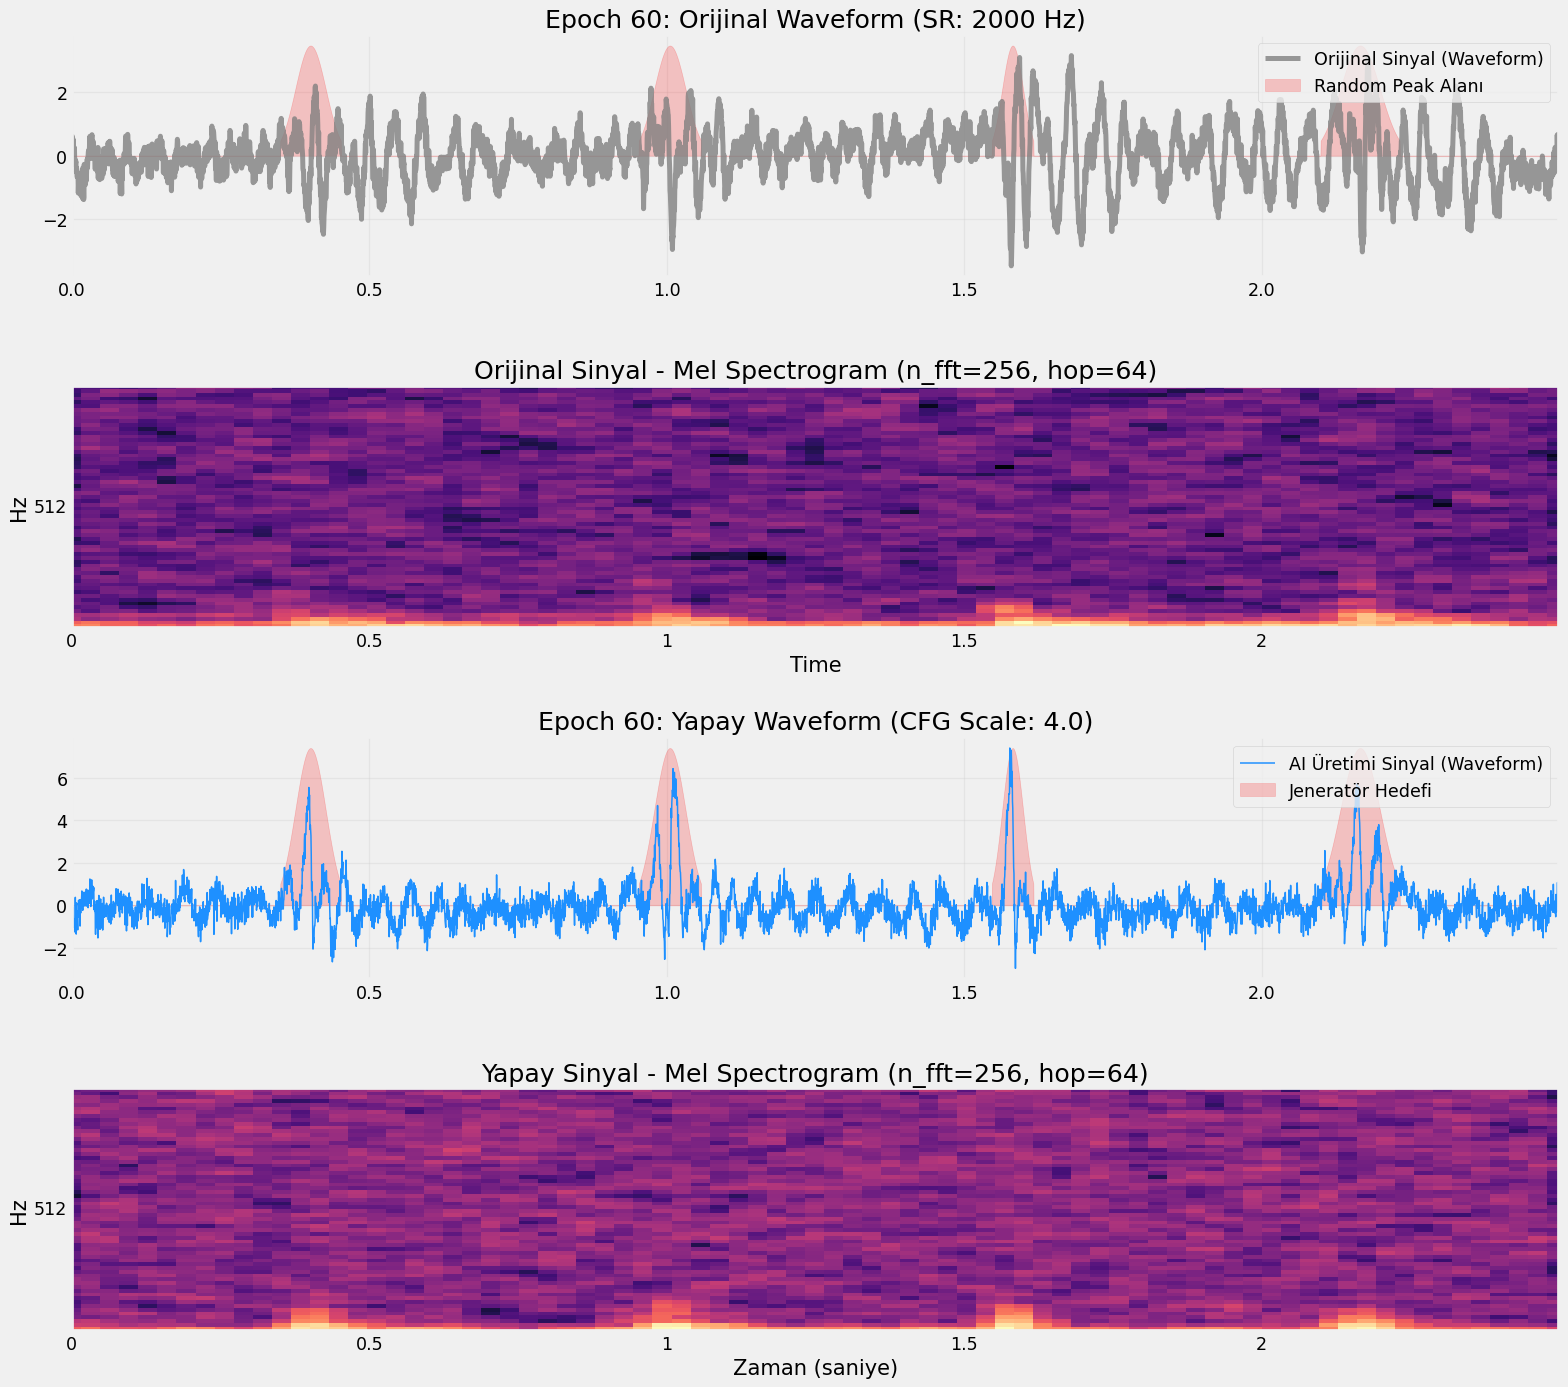

💾 Epoch 60 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 61 BAŞLADI ---
Epoch 61 | Step 856/856 | Diffusion Loss (MSE): 0.0427
Epoch 61 Özet | Avg Diffusion Loss: 0.1083 | Süre: 188.7 sn
--- EPOCH 62 BAŞLADI ---
Epoch 62 | Step 856/856 | Diffusion Loss (MSE): 0.0820
Epoch 62 Özet | Avg Diffusion Loss: 0.1063 | Süre: 177.3 sn
--- EPOCH 63 BAŞLADI ---
Epoch 63 | Step 856/856 | Diffusion Loss (MSE): 0.2567
Epoch 63 Özet | Avg Diffusion Loss: 0.1081 | Süre: 177.8 sn
--- EPOCH 64 BAŞLADI ---
Epoch 64 | Step 856/856 | Diffusion Loss (MSE): 0.0292
Epoch 64 Özet | Avg Diffusion Loss: 0.1080 | Süre: 177.6 sn
--- EPOCH 65 BAŞLADI ---
Epoch 65 | Step 856/856 | Diffusion Loss (MSE): 0.0244
Epoch 65 Özet | Avg Diffusion Loss: 0.1049 | Süre: 177.5 sn
Epoch 65 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 65 Denoising: 100%|██████████| 1000/1000 [07:50<00:00,  2.12it/s]


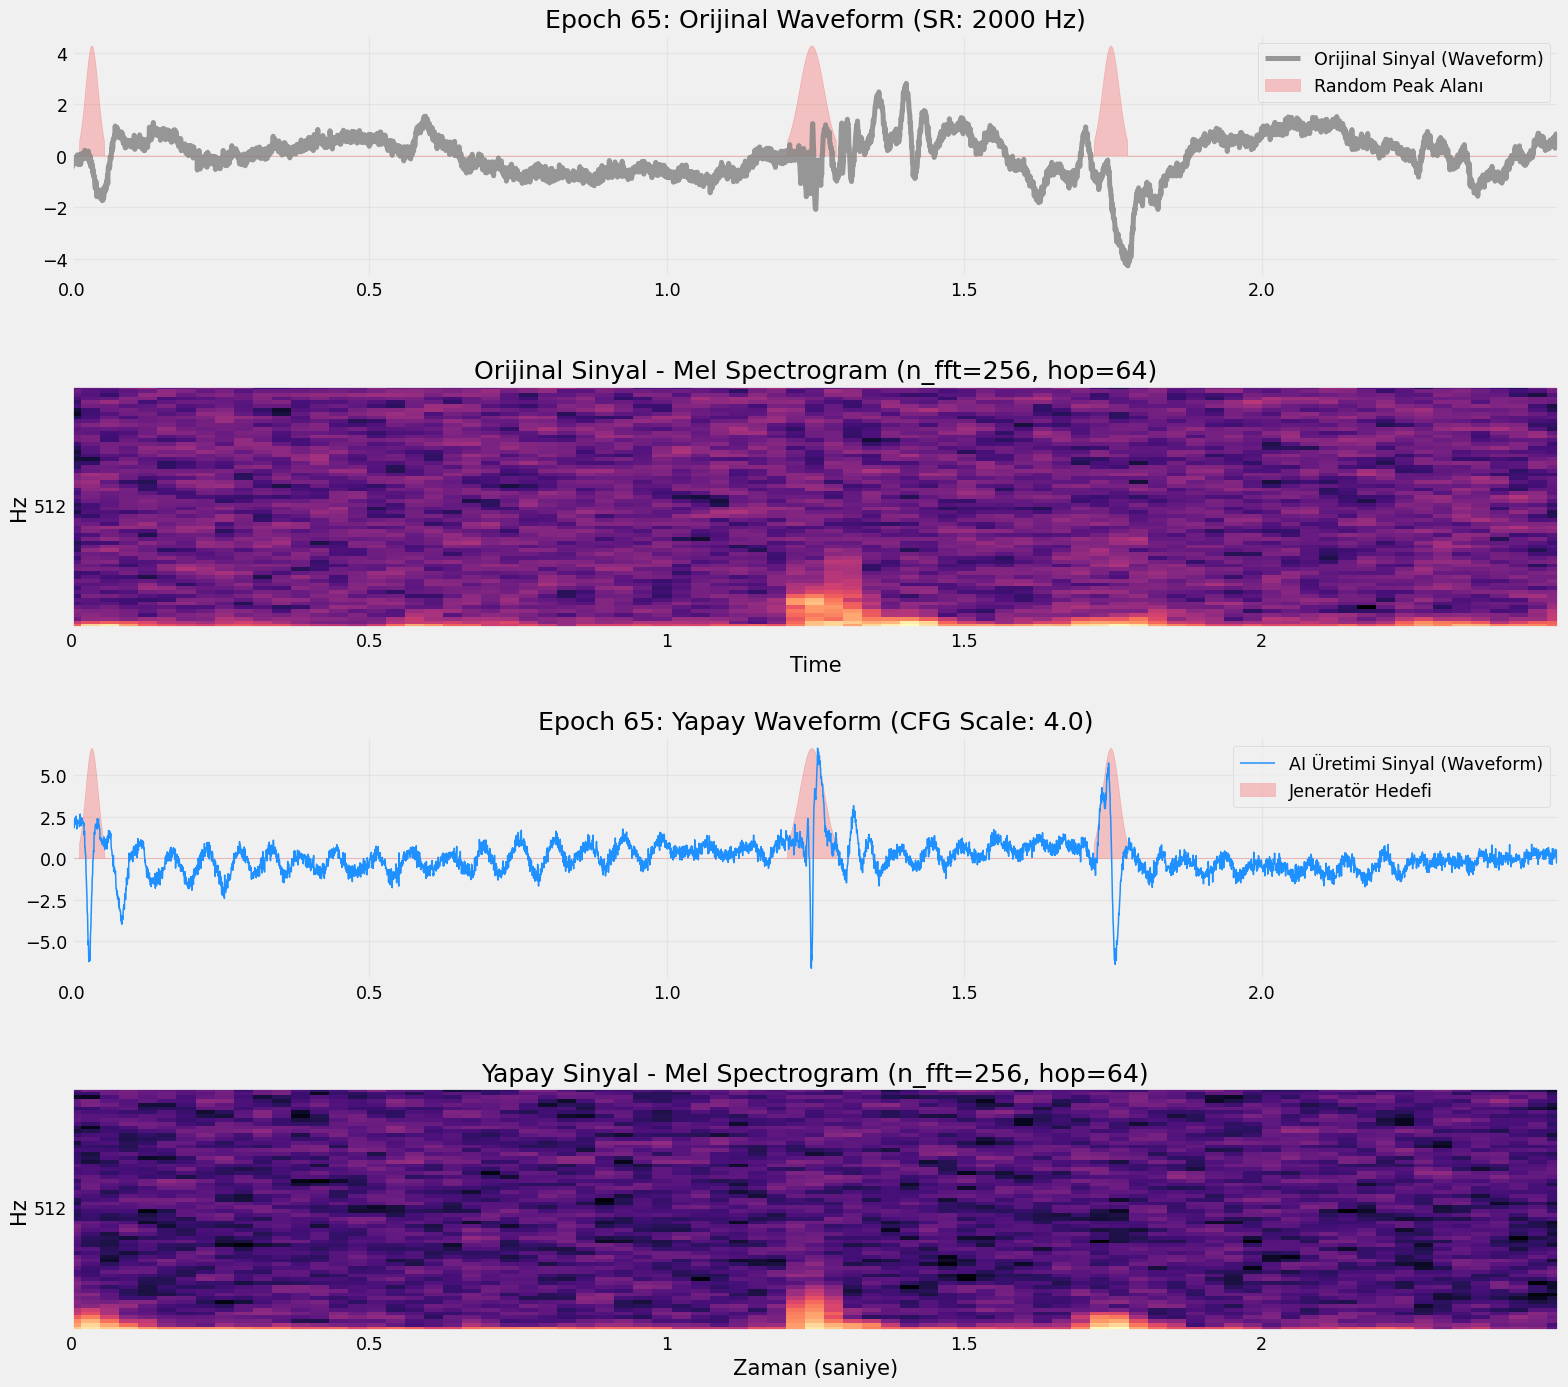

💾 Epoch 65 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 66 BAŞLADI ---
Epoch 66 | Step 856/856 | Diffusion Loss (MSE): 0.1025
Epoch 66 Özet | Avg Diffusion Loss: 0.1089 | Süre: 185.8 sn
--- EPOCH 67 BAŞLADI ---
Epoch 67 | Step 856/856 | Diffusion Loss (MSE): 0.0182
Epoch 67 Özet | Avg Diffusion Loss: 0.1090 | Süre: 177.4 sn
--- EPOCH 68 BAŞLADI ---
Epoch 68 | Step 856/856 | Diffusion Loss (MSE): 0.0129
Epoch 68 Özet | Avg Diffusion Loss: 0.1097 | Süre: 177.5 sn
--- EPOCH 69 BAŞLADI ---
Epoch 69 | Step 856/856 | Diffusion Loss (MSE): 0.6573
Epoch 69 Özet | Avg Diffusion Loss: 0.1099 | Süre: 177.7 sn
--- EPOCH 70 BAŞLADI ---
Epoch 70 | Step 856/856 | Diffusion Loss (MSE): 0.0702
Epoch 70 Özet | Avg Diffusion Loss: 0.1067 | Süre: 177.6 sn
Epoch 70 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 70 Denoising: 100%|██████████| 1000/1000 [07:54<00:00,  2.11it/s]


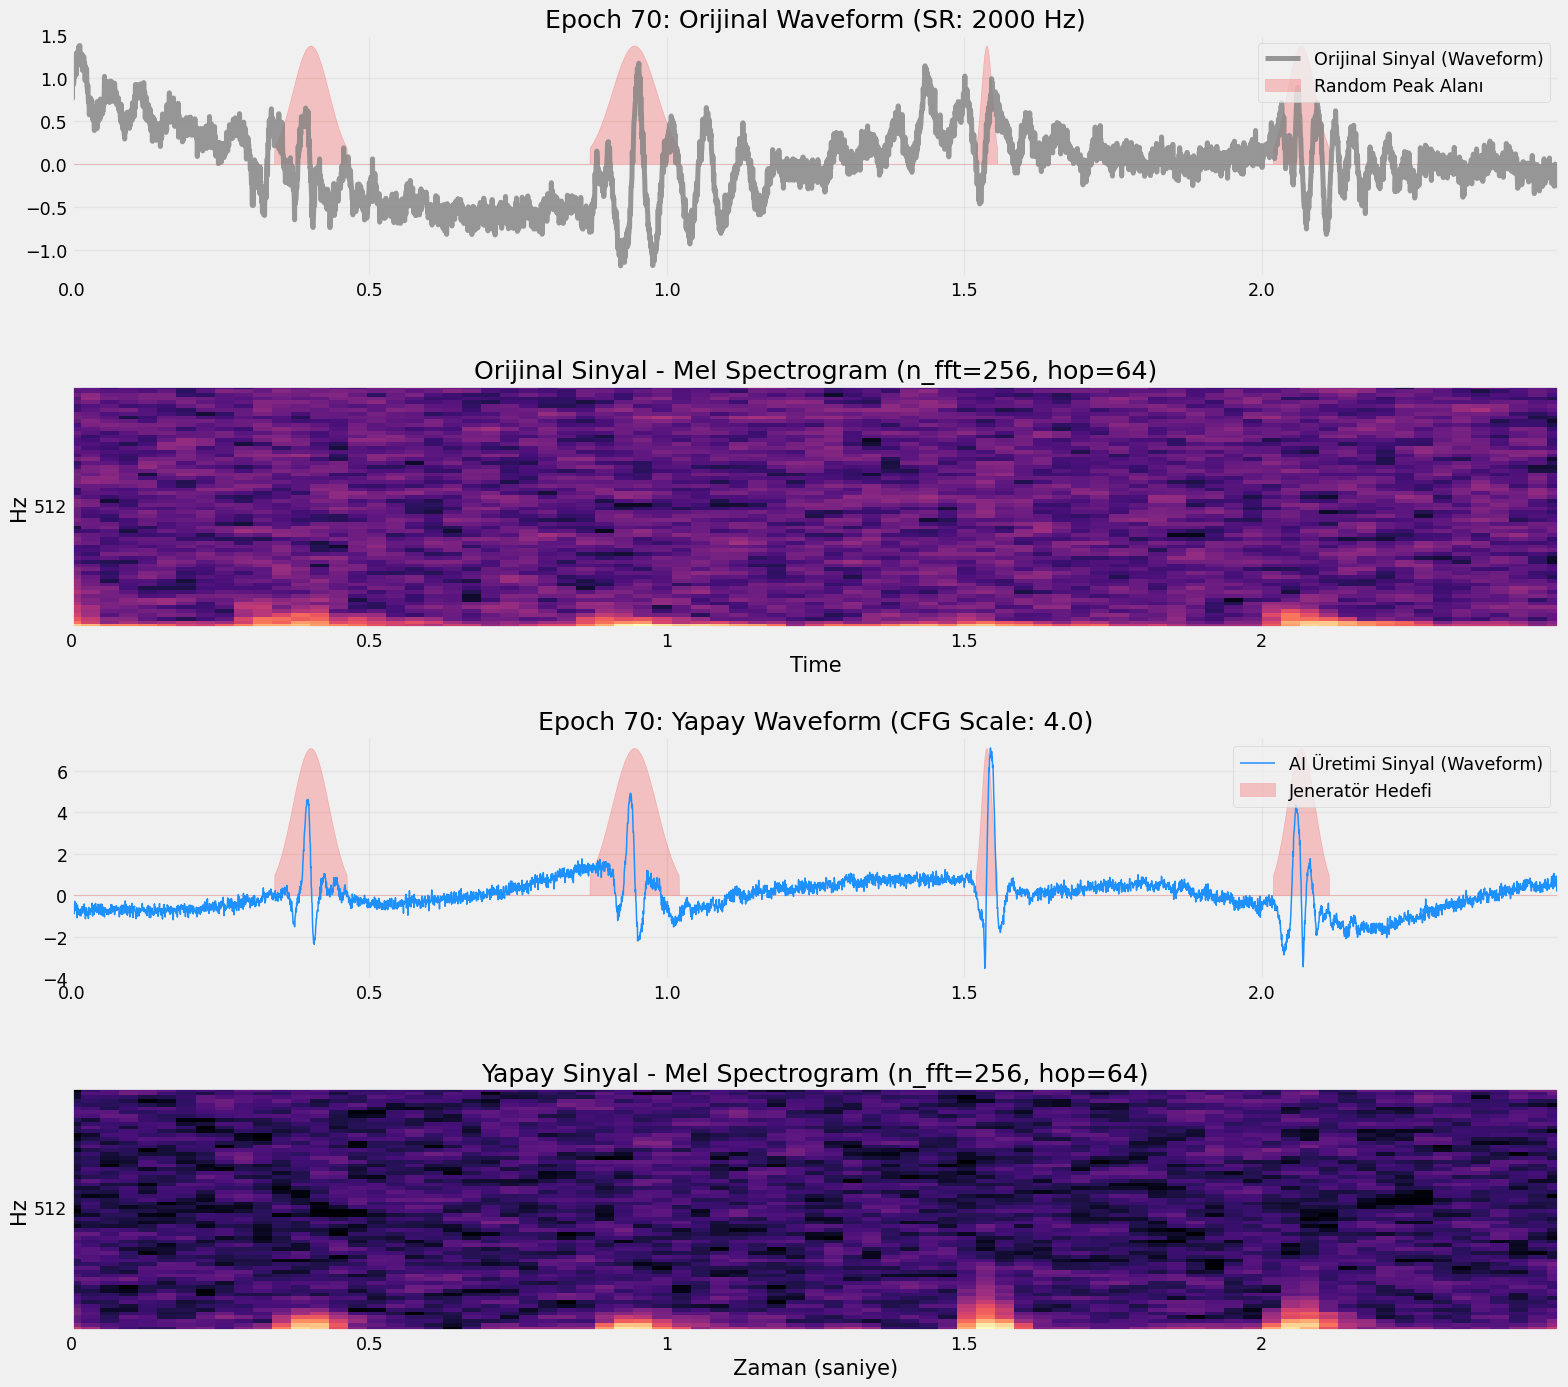

💾 Epoch 70 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 71 BAŞLADI ---
Epoch 71 | Step 856/856 | Diffusion Loss (MSE): 0.4065
Epoch 71 Özet | Avg Diffusion Loss: 0.1094 | Süre: 177.2 sn
--- EPOCH 72 BAŞLADI ---
Epoch 72 | Step 856/856 | Diffusion Loss (MSE): 0.3793
Epoch 72 Özet | Avg Diffusion Loss: 0.1078 | Süre: 177.4 sn
--- EPOCH 73 BAŞLADI ---
Epoch 73 | Step 856/856 | Diffusion Loss (MSE): 0.0566
Epoch 73 Özet | Avg Diffusion Loss: 0.1058 | Süre: 177.6 sn
--- EPOCH 74 BAŞLADI ---
Epoch 74 | Step 856/856 | Diffusion Loss (MSE): 0.4011
Epoch 74 Özet | Avg Diffusion Loss: 0.1059 | Süre: 177.5 sn
--- EPOCH 75 BAŞLADI ---
Epoch 75 | Step 856/856 | Diffusion Loss (MSE): 0.0495
Epoch 75 Özet | Avg Diffusion Loss: 0.1091 | Süre: 177.6 sn
Epoch 75 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 75 Denoising: 100%|██████████| 1000/1000 [07:42<00:00,  2.16it/s]


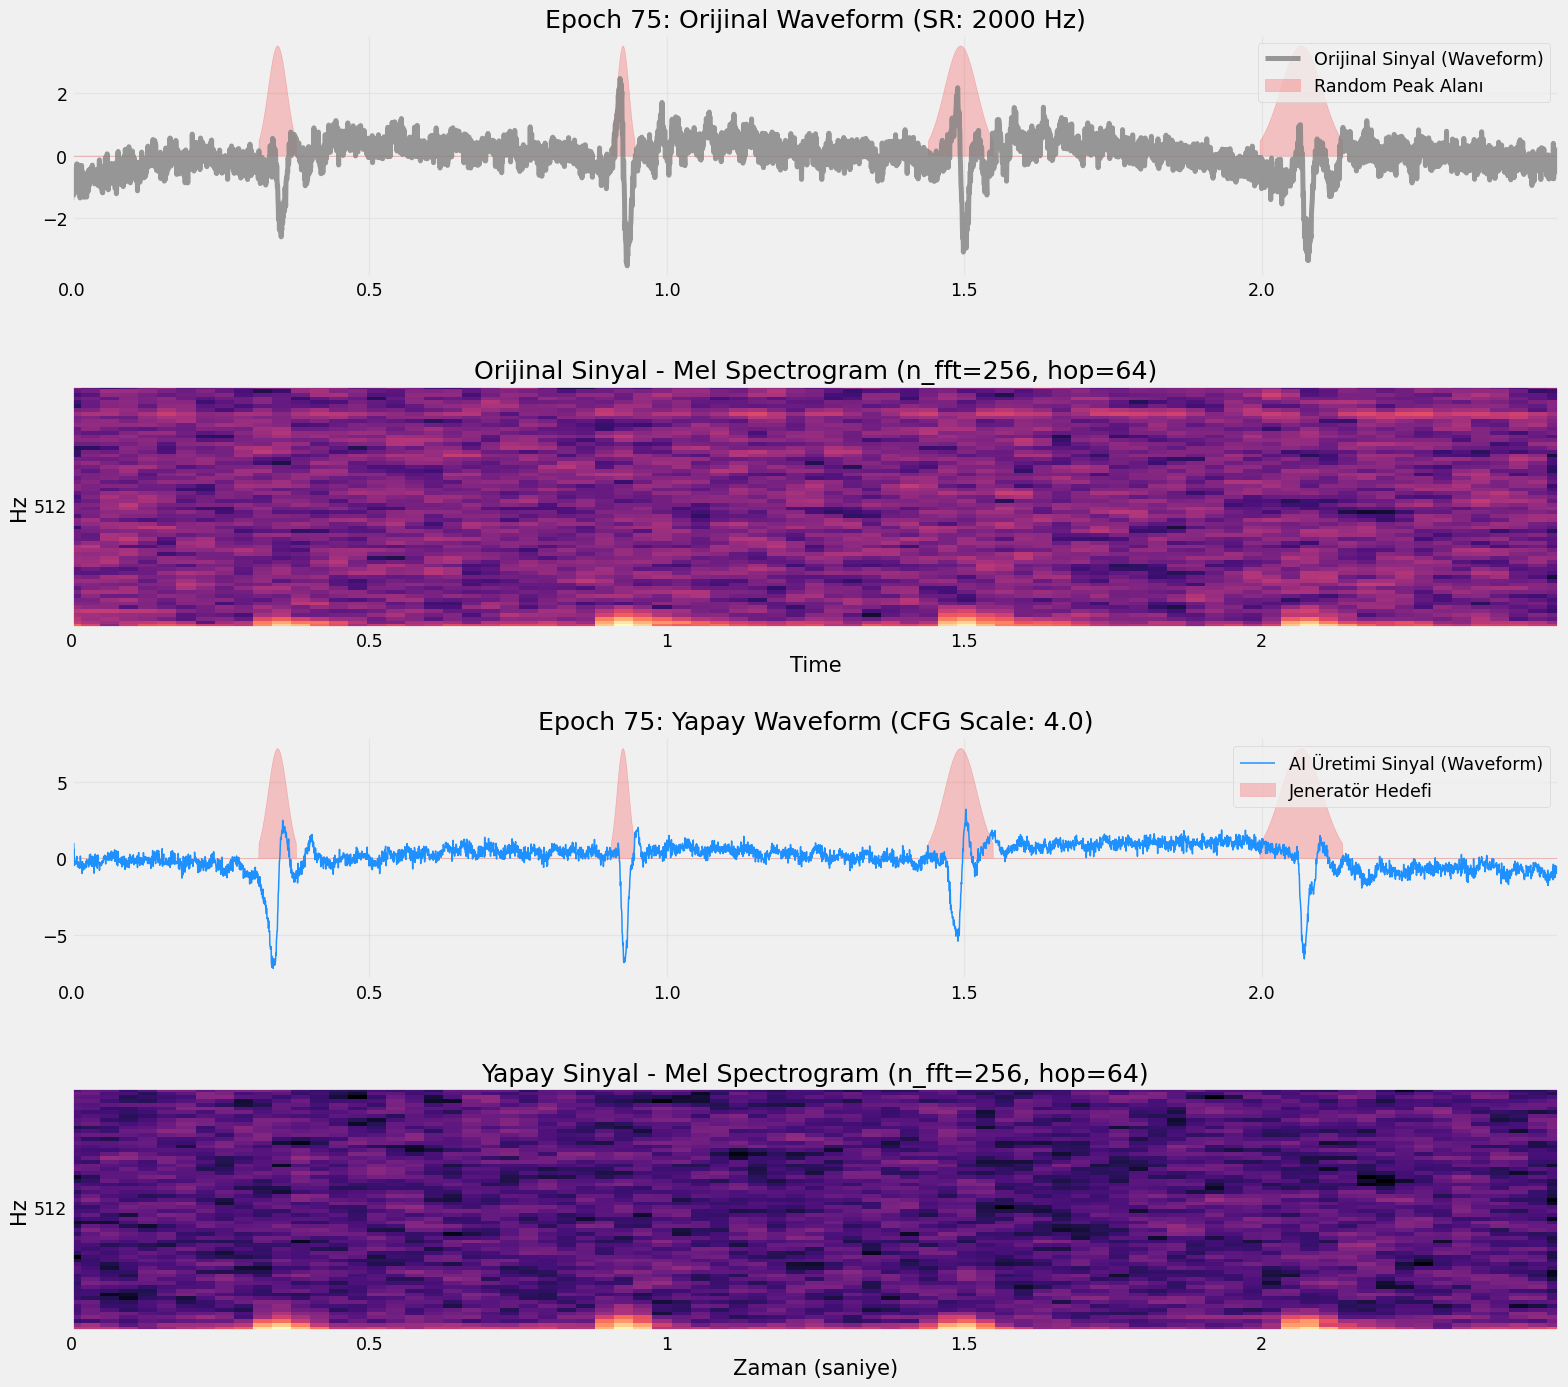

💾 Epoch 75 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 76 BAŞLADI ---
Epoch 76 | Step 856/856 | Diffusion Loss (MSE): 0.4540
Epoch 76 Özet | Avg Diffusion Loss: 0.1040 | Süre: 177.1 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 76 - Loss: 0.1040)
--- EPOCH 77 BAŞLADI ---
Epoch 77 | Step 856/856 | Diffusion Loss (MSE): 0.0434
Epoch 77 Özet | Avg Diffusion Loss: 0.1056 | Süre: 177.2 sn
--- EPOCH 78 BAŞLADI ---
Epoch 78 | Step 856/856 | Diffusion Loss (MSE): 0.7585
Epoch 78 Özet | Avg Diffusion Loss: 0.1081 | Süre: 177.4 sn
--- EPOCH 79 BAŞLADI ---
Epoch 79 | Step 856/856 | Diffusion Loss (MSE): 0.1930
Epoch 79 Özet | Avg Diffusion Loss: 0.1094 | Süre: 178.2 sn
--- EPOCH 80 BAŞLADI ---
Epoch 80 | Step 856/856 | Diffusion Loss (MSE): 0.0064
Epoch 80 Özet | Avg Diffusion Loss: 0.1063 | Süre: 177.7 sn
Epoch 80 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 80 Denoising: 100%|██████████| 1000/1000 [07:51<00:00,  2.12it/s]


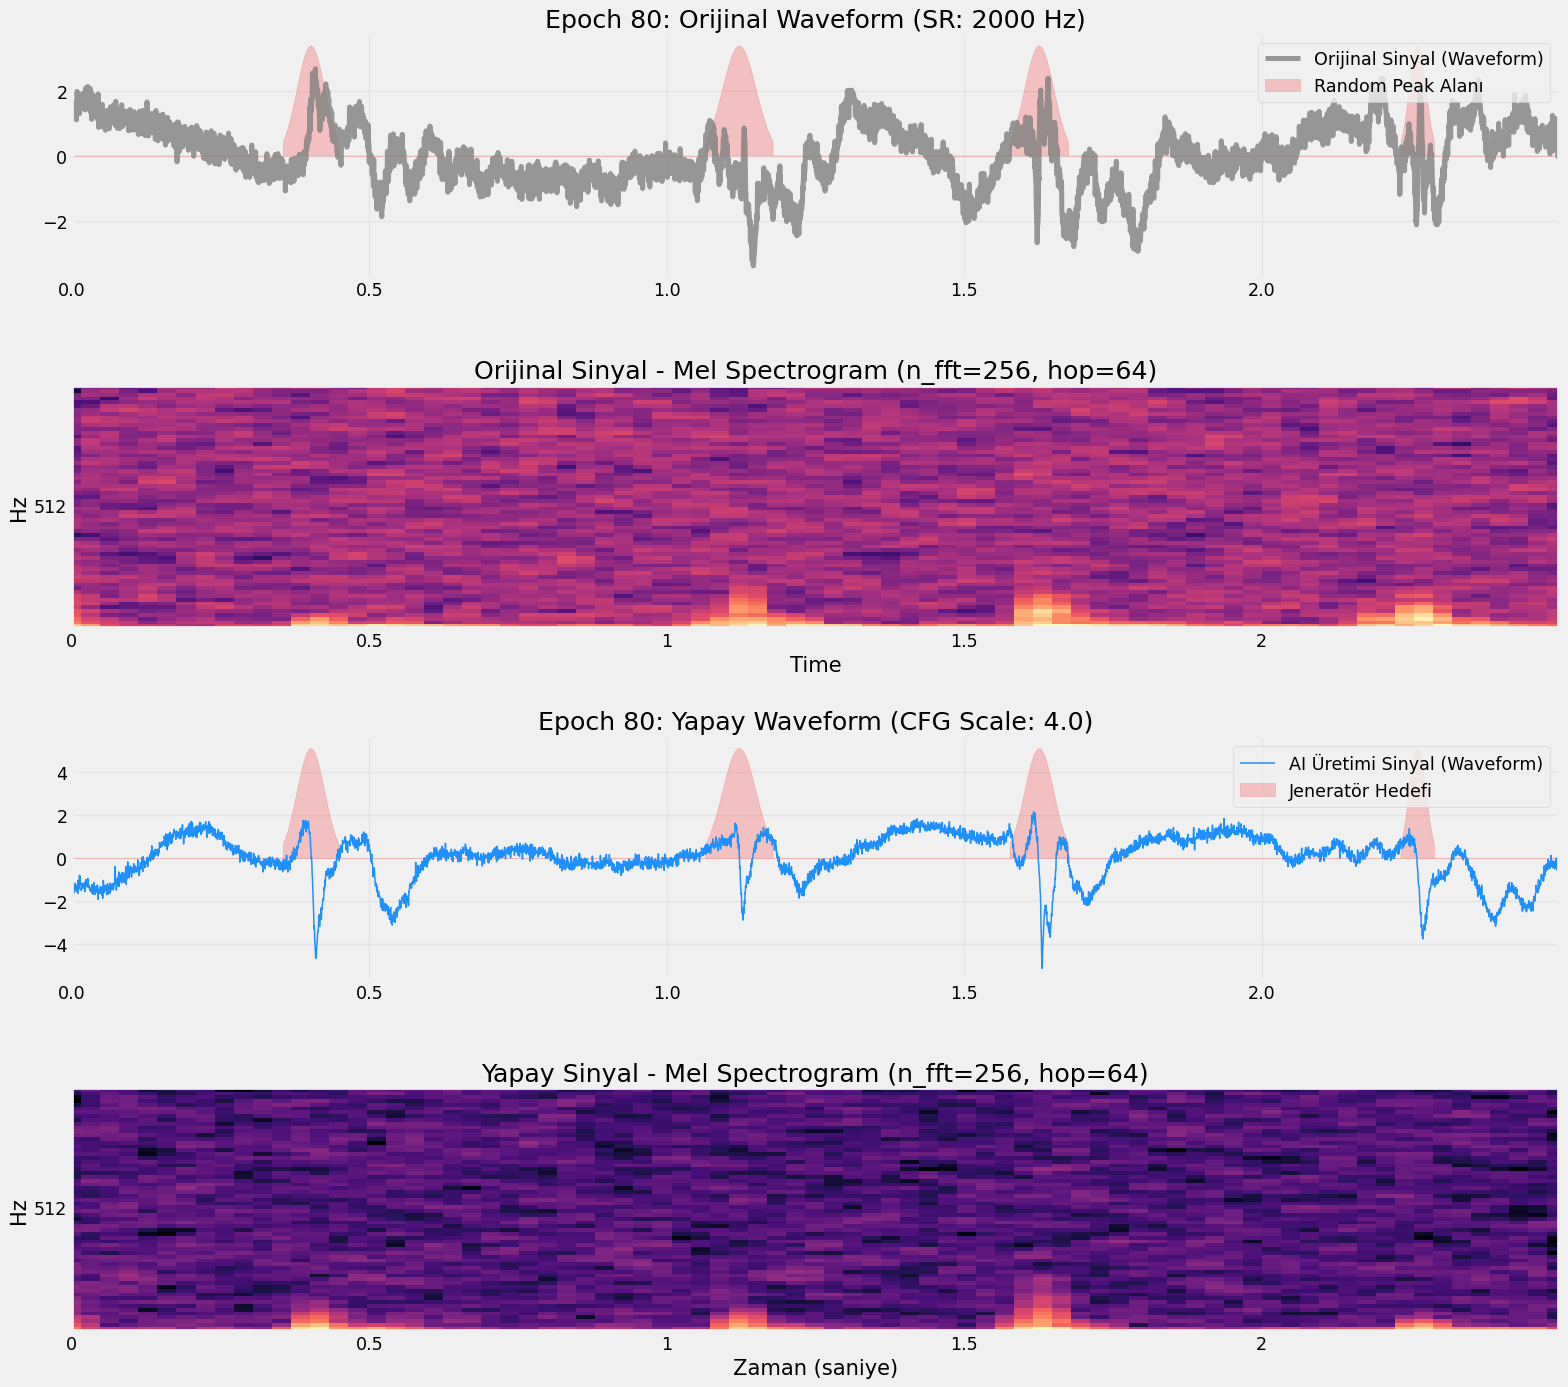

💾 Epoch 80 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 81 BAŞLADI ---
Epoch 81 | Step 856/856 | Diffusion Loss (MSE): 0.4669
Epoch 81 Özet | Avg Diffusion Loss: 0.1074 | Süre: 191.6 sn
--- EPOCH 82 BAŞLADI ---
Epoch 82 | Step 856/856 | Diffusion Loss (MSE): 0.1377
Epoch 82 Özet | Avg Diffusion Loss: 0.1058 | Süre: 190.0 sn
--- EPOCH 83 BAŞLADI ---
Epoch 83 | Step 856/856 | Diffusion Loss (MSE): 0.2138
Epoch 83 Özet | Avg Diffusion Loss: 0.1079 | Süre: 191.7 sn
--- EPOCH 84 BAŞLADI ---
Epoch 84 | Step 856/856 | Diffusion Loss (MSE): 0.0075
Epoch 84 Özet | Avg Diffusion Loss: 0.1037 | Süre: 177.5 sn
🌟 Yeni En İyi Başarı! (Best Epoch şu an: 84 - Loss: 0.1037)
--- EPOCH 85 BAŞLADI ---
Epoch 85 | Step 856/856 | Diffusion Loss (MSE): 0.0263
Epoch 85 Özet | Avg Diffusion Loss: 0.1070 | Süre: 177.6 sn
Epoch 85 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 85 Denoising: 100%|██████████| 1000/1000 [07:45<00:00,  2.15it/s]


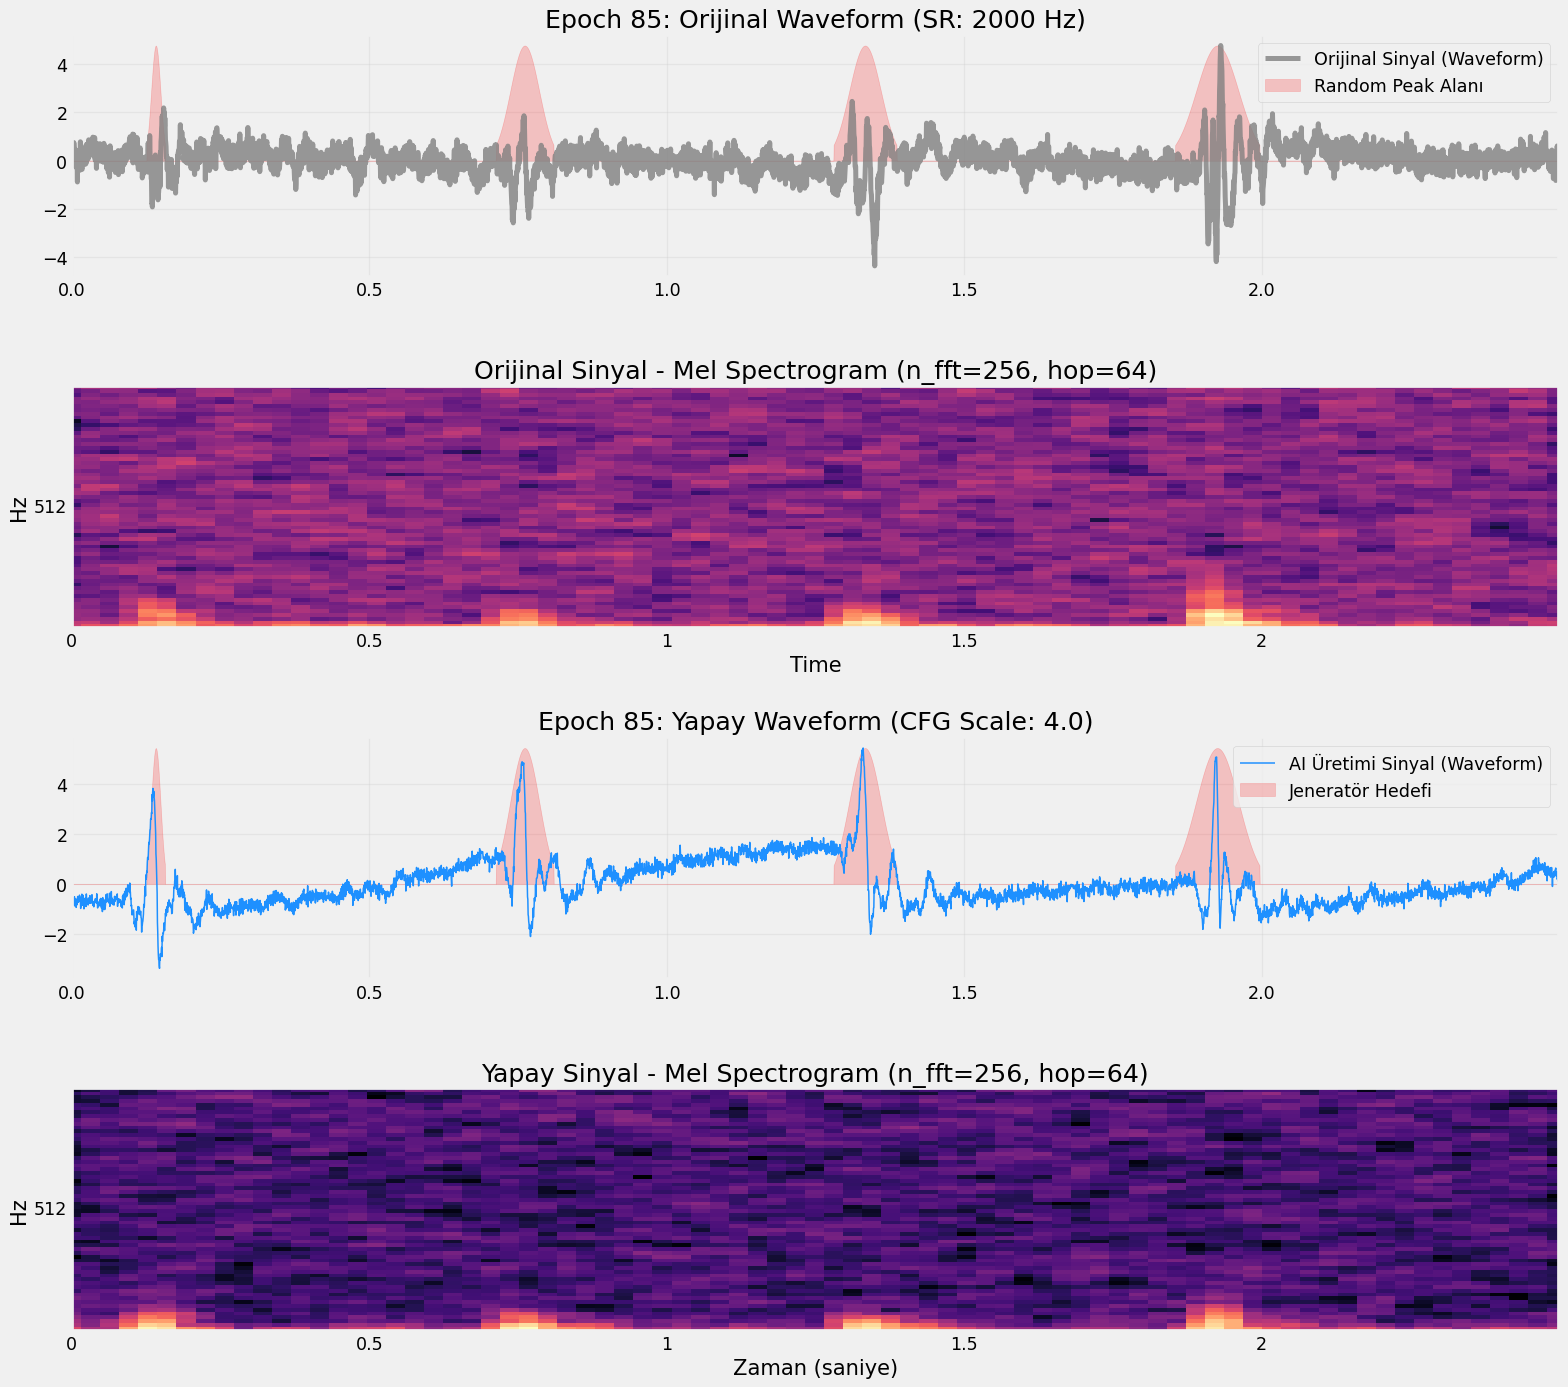

💾 Epoch 85 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 86 BAŞLADI ---
Epoch 86 | Step 856/856 | Diffusion Loss (MSE): 0.0139
Epoch 86 Özet | Avg Diffusion Loss: 0.1083 | Süre: 177.2 sn
--- EPOCH 87 BAŞLADI ---
Epoch 87 | Step 856/856 | Diffusion Loss (MSE): 0.0445
Epoch 87 Özet | Avg Diffusion Loss: 0.1078 | Süre: 177.5 sn
--- EPOCH 88 BAŞLADI ---
Epoch 88 | Step 856/856 | Diffusion Loss (MSE): 0.0382
Epoch 88 Özet | Avg Diffusion Loss: 0.1066 | Süre: 177.8 sn
--- EPOCH 89 BAŞLADI ---
Epoch 89 | Step 856/856 | Diffusion Loss (MSE): 0.0674
Epoch 89 Özet | Avg Diffusion Loss: 0.1054 | Süre: 177.7 sn
--- EPOCH 90 BAŞLADI ---
Epoch 90 | Step 856/856 | Diffusion Loss (MSE): 0.0010
Epoch 90 Özet | Avg Diffusion Loss: 0.1051 | Süre: 177.6 sn
Epoch 90 için sinyal sentezleniyor (CFG Scale: 4.0)...


Ep 90 Denoising: 100%|██████████| 1000/1000 [07:54<00:00,  2.11it/s]


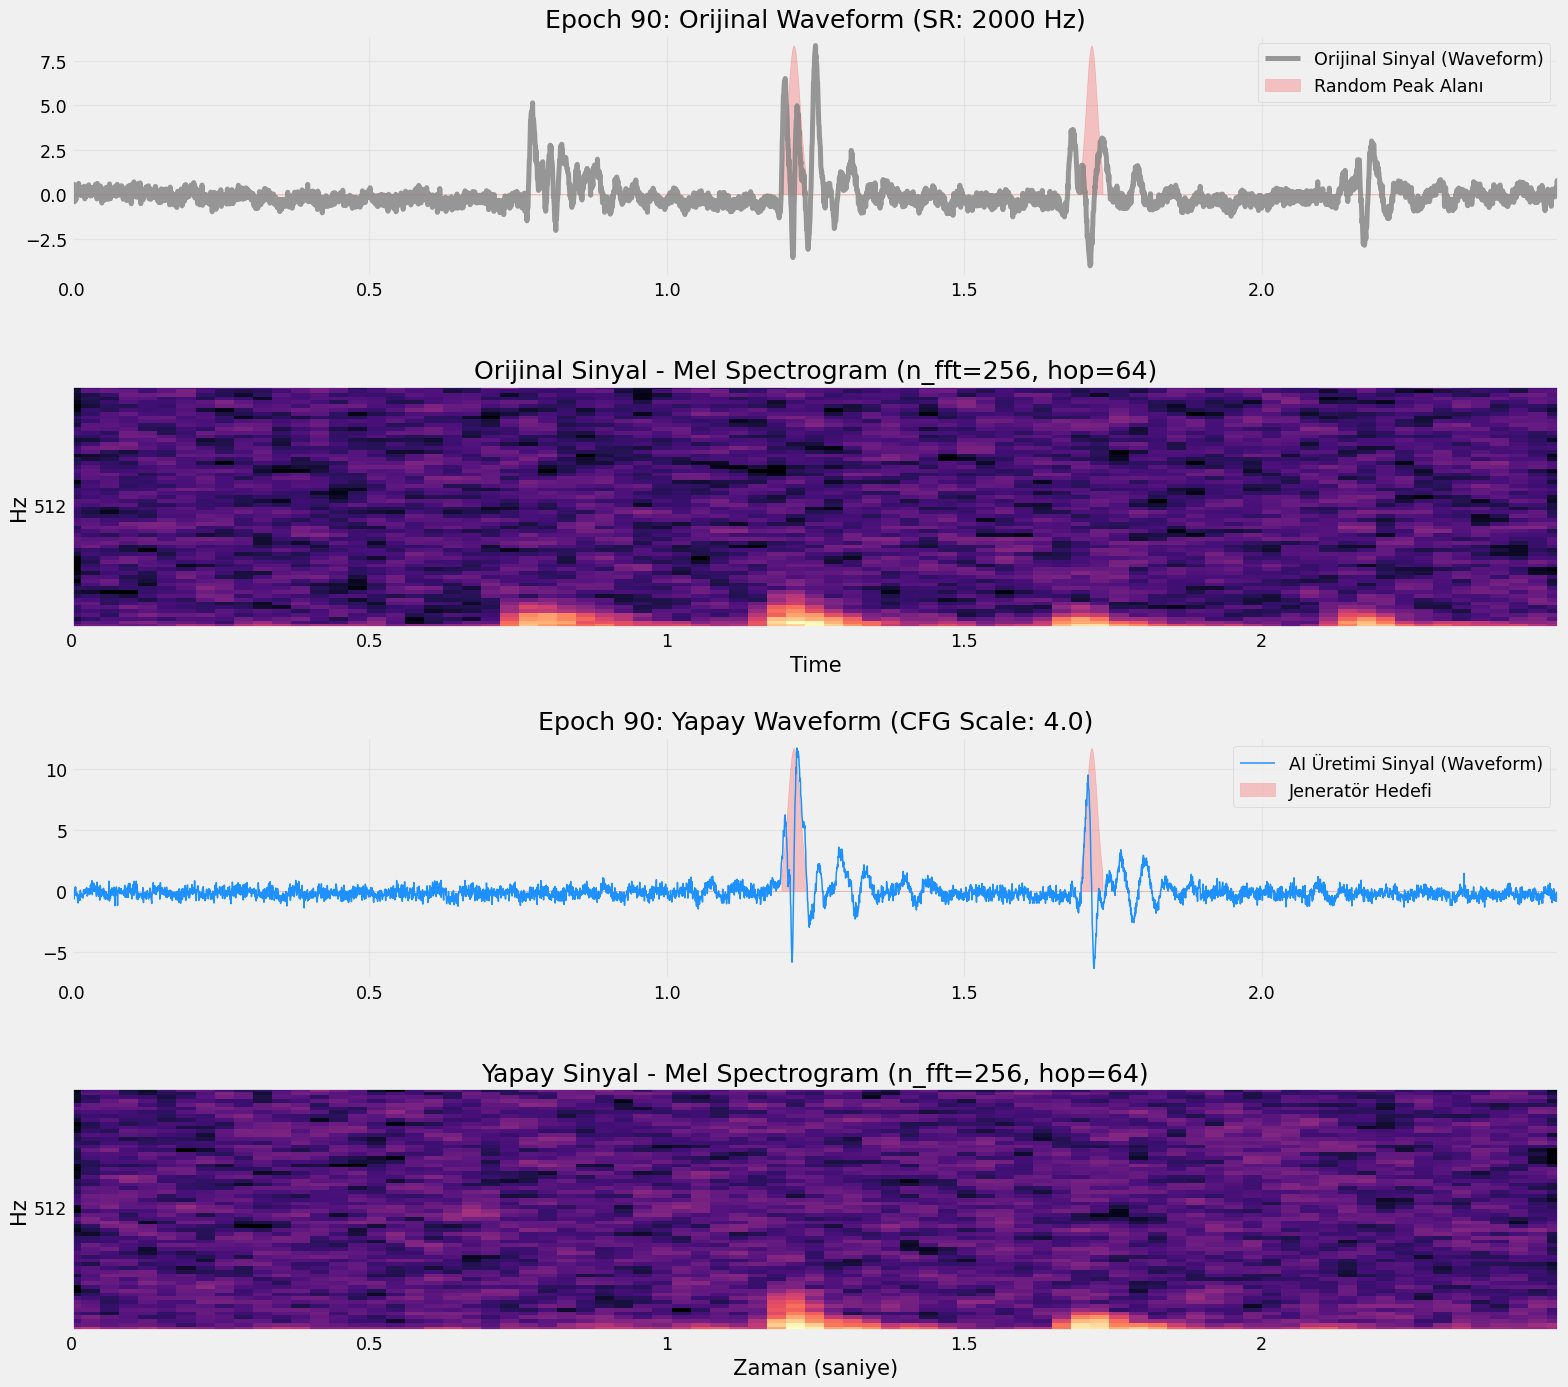

💾 Epoch 90 görselleri ve ağırlıkları başarıyla kaydedildi.
--- EPOCH 91 BAŞLADI ---
Epoch 91 | Step 311/856 | Diffusion Loss (MSE): 0.1372

In [ ]:
import time
import tensorflow as tf
import os

EPOCHS = 500
best_diff_loss = float('inf') 
best_epoch_num = 0

# CFG Gücünü buradan yönetebilirsin (Vitrin çizimleri için)
CFG_SCALE = 4.0 

weights_dir = os.path.join(MODEL_FOLDER, "weights")
os.makedirs(weights_dir, exist_ok=True)

for epoch in range(EPOCHS):
    start = time.time()
    
    epoch_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    
    for step in range(total_steps):
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        enc_masks = tf.convert_to_tensor(batch_data[:, :, 2:3], dtype=tf.float32)
        
        loss = train_step(real_sigs, peaks, enc_masks)
        
        epoch_loss.append(loss)
        
        print(f"Epoch {epoch+1} | Step {step+1}/{total_steps} | Diffusion Loss (MSE): {loss:.4f}", end='\r', flush=True)

    avg_loss = tf.reduce_mean(epoch_loss).numpy()
    
    print(f"\nEpoch {epoch+1} Özet | Avg Diffusion Loss: {avg_loss:.4f} | Süre: {time.time() - start:.1f} sn")
    
    # BEST EPOCH TAKİBİ
    if avg_loss < best_diff_loss:
        best_diff_loss = avg_loss
        best_epoch_num = epoch + 1
        print(f"🌟 Yeni En İyi Başarı! (Best Epoch şu an: {best_epoch_num} - Loss: {best_diff_loss:.4f})")

    if (epoch + 1) % 5 == 0:
        # +++ GÜNCELLEME: guidance_scale parametresi eklendi +++
        visualize_epoch_results(epoch, encoder, diffusion_unet, train_seq, MODEL_FOLDER, guidance_scale=CFG_SCALE)
        
        enc_weight_path = os.path.join(weights_dir, f"encoder_epoch_{epoch+1}.weights.h5")
        unet_weight_path = os.path.join(weights_dir, f"diffusion_unet_epoch_{epoch+1}.weights.h5")
        
        encoder.save_weights(enc_weight_path)
        diffusion_unet.save_weights(unet_weight_path) 
        print(f"💾 Epoch {epoch+1} görselleri ve ağırlıkları başarıyla kaydedildi.")

print(f"\n✅ EĞİTİM BİTTİ! Matematiksel Olarak En İyi Epoch: {best_epoch_num}")
print(f"Tüm ağırlıklar ve görseller '{MODEL_FOLDER}' klasöründe incelenmeyi bekliyor.")